# MUTCD Multimodal RAG (v3) — Colab / HPRC

Hierarchical hybrid retrieval (dense + sparse + knowledge-graph proximity +
rule-type weighting) over the MUTCD 11th Edition, with a VLM answer step
that can run either **locally on GPU** or via an **API** (Qwen3-VL-32B by
default through DashScope).

Run cells top to bottom, once per session.

## 0. First-cell setup (Colab) — skip this entire section on HPRC

In [1]:
# COLAB ONLY — comment out this whole cell if running on HPRC.
import os
import stat
import subprocess
import sys
from pathlib import Path

# Google Drive persists the PDF, Qdrant snapshot, caches, model-registry override,
# and benchmark outputs. Runtime code and the question-only benchmark come from GitHub.
from google.colab import drive, userdata
drive.mount("/content/drive", force_remount=False)

os.environ["MRAG_ENV"] = "colab"

# Repository settings. Override with environment variables before running this cell
# only when using another fork or branch.
MRAG_REPO_URL = os.environ.get(
    "MRAG_REPO_URL", "https://github.com/hannanazad/MRAG_stp2.git"
)
MRAG_REPO_BRANCH = os.environ.get("MRAG_REPO_BRANCH", "main")
MRAG_REPO_DIR = Path(os.environ.get("MRAG_REPO_DIR", "/content/MRAG"))

# Optional private-repository authentication.
# Put a fine-grained GitHub token in Colab Secrets as GITHUB_TOKEN. The token is
# supplied through an ephemeral askpass helper and is never inserted into the URL.
try:
    github_token = userdata.get("GITHUB_TOKEN")
except Exception:
    github_token = None

if github_token:
    os.environ["GITHUB_TOKEN"] = github_token
    askpass = Path("/content/.git_askpass_mutcd.sh")
    askpass.write_text(
        '#!/bin/sh\ncase "$1" in\n  *Username*) echo "x-access-token" ;;\n  *) echo "$GITHUB_TOKEN" ;;\nesac\n',
        encoding="utf-8",
    )
    askpass.chmod(stat.S_IRUSR | stat.S_IWUSR | stat.S_IXUSR)
    os.environ["GIT_ASKPASS"] = str(askpass)
    os.environ["GIT_TERMINAL_PROMPT"] = "0"


def _run_git(*args: str) -> None:
    subprocess.run(["git", *args], check=True)


if not (MRAG_REPO_DIR / ".git").exists():
    _run_git(
        "clone",
        "--branch", MRAG_REPO_BRANCH,
        "--single-branch",
        MRAG_REPO_URL,
        str(MRAG_REPO_DIR),
    )
else:
    _run_git("-C", str(MRAG_REPO_DIR), "fetch", "origin", MRAG_REPO_BRANCH)
    _run_git("-C", str(MRAG_REPO_DIR), "checkout", MRAG_REPO_BRANCH)
    # Fast-forward only: never create an accidental merge in a benchmark runtime.
    _run_git("-C", str(MRAG_REPO_DIR), "pull", "--ff-only", "origin", MRAG_REPO_BRANCH)

repo_commit = subprocess.check_output(
    ["git", "-C", str(MRAG_REPO_DIR), "rev-parse", "HEAD"], text=True
).strip()
print("Repository:", MRAG_REPO_URL)
print("Branch    :", MRAG_REPO_BRANCH)
print("Commit    :", repo_commit)

sys.path.insert(0, str(MRAG_REPO_DIR))

# Step 1 — torch + torchvision matched to Colab's CUDA 12.4.
subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q",
        "--index-url", "https://download.pytorch.org/whl/cu124",
        "torch==2.6.0", "torchvision==0.21.0",
    ],
    check=True,
)

# Step 2 — project dependencies.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", str(MRAG_REPO_DIR / "requirements.txt")],
    check=True,
)

# Step 3 — force compatible ceilings for Colab's preinstalled packages.
subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q", "--no-deps", "--force-reinstall",
        "transformers>=4.49,<4.55",
        "huggingface_hub>=0.34,<0.35",
        "tokenizers>=0.21,<0.22",
        "torchao>=0.13,<0.14",
    ],
    check=True,
)

# Step 4 — sanity check.
subprocess.run(
    [sys.executable, "-c", "from transformers import PreTrainedModel; print('transformers import OK:', PreTrainedModel.__name__)"],
    check=True,
)


Mounted at /content/drive
Cloning into '/content/MRAG'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 98 (delta 36), reused 55 (delta 23), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 1.62 MiB | 6.70 MiB/s, done.
Resolving deltas: 100% (36/36), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 116.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 69.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 151.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 46.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.9 MB/

In [2]:
# Paste your Qwen API key into Colab Secrets (key icon, left sidebar) under
# the name shown below, then run this cell. Never hard-code the key directly.
from google.colab import userdata
import os

SECRET_NAME = "QWEN" # <- the name you used in the Secrets panel

os.environ["VLM_API_KEY"] = userdata.get(SECRET_NAME)
print("API key set:", bool(os.environ.get("VLM_API_KEY")))


API key set: True


## 1. Environment sanity check (both Colab and HPRC)

In [3]:
import os, sys
sys.path.insert(0, "/content/MRAG" if os.path.isdir("/content/MRAG") else ".")

from mrag.config import CFG

print("Environment :", CFG.environment)
print("Base dir    :", CFG.base_dir, "| exists:", CFG.base_dir.exists())
print("PDF path    :", CFG.pdf_path, "| exists:", CFG.pdf_path.exists())
print("Qdrant dir  :", CFG.qdrant_dir)
print("Cache dir   :", CFG.cache_dir)
print("HF cache    :", CFG.hf_home)
print("VLM provider:", CFG.vlm_provider)
print("VLM model   :", CFG.vlm_model_api if CFG.vlm_provider == "api" else CFG.vlm_model)
print("API key set :", bool(os.environ.get(CFG.api_key_env_var)))

assert CFG.pdf_path.exists(), (
    f"No PDF found at {CFG.pdf_path} or anywhere in {CFG.base_dir}. "
    f"Upload the MUTCD PDF to {CFG.base_dir} before continuing."
)


Environment : colab
Base dir    : /content/drive/MyDrive/MRAG | exists: True
PDF path    : /content/drive/MyDrive/MRAG/mutcd11theditionr1hl.pdf | exists: True
Qdrant dir  : /content/qdrant_db
Cache dir   : /content/drive/MyDrive/MRAG/mmrag_cache_v3
HF cache    : /content/drive/MyDrive/MRAG/hf_cache
VLM provider: api
VLM model   : qwen3-vl-plus-2025-12-19
API key set : True


## 1.5 Recover or build the Qdrant vector store

If you've run ingestion successfully before, this restores the existing
Drive snapshot into the fast local Colab disk in seconds. If no snapshot
exists yet, it falls through to running full ingestion (first time only,
~30–45 min; subsequent reruns are much faster since chunks/figures/KG are
cached and only re-embedding + upsert happens, ~5 min).

In [4]:
import shutil, tarfile, json
from pathlib import Path
from qdrant_client import QdrantClient

local_qdrant = CFG.qdrant_dir                      # /content/qdrant_db (fast local SSD)
drive_qdrant_tar = CFG.base_dir / "qdrant_db.tar"  # snapshot on Drive

def _qdrant_ok(path: Path) -> bool:
    if not path.exists():
        return False
    try:
        c = QdrantClient(path=str(path))
        try:
            names = {col.name for col in c.get_collections().collections}
            return CFG.coll_chunks in names
        finally:
            c.close()
    except Exception:
        return False

def _v4_done() -> bool:
    """True once the v4 (caption-below) figure extraction has run — the
    signal that crops, KG, and figure embeddings are the corrected ones."""
    try:
        with open(CFG.figures_jsonl) as f:
            first = json.loads(next(f))
        return str(first.get("extraction_method", "")).startswith("caption_below_v2")
    except Exception:
        return False

if _qdrant_ok(local_qdrant) and _v4_done():
    print(f"Qdrant populated at {local_qdrant} and figures are v4. Nothing to do.")

elif drive_qdrant_tar.exists() and _v4_done():
    # NOTE: this assumes the tar was snapshotted AFTER the first v4 ingest
    # (cell 1.6). If it predates v4, delete Drive/MRAG/qdrant_db.tar once and
    # re-run this cell.
    print(f"Restoring v4 Qdrant snapshot from {drive_qdrant_tar} "
          f"({drive_qdrant_tar.stat().st_size/1e6:.0f} MB)...")
    shutil.rmtree(local_qdrant, ignore_errors=True)
    local_qdrant.mkdir(parents=True, exist_ok=True)
    with tarfile.open(drive_qdrant_tar, "r") as tar:
        tar.extractall(local_qdrant.parent)
    assert _qdrant_ok(local_qdrant), "Extraction completed but collection not found."
    print("Local Qdrant verified OK.")

else:
    if drive_qdrant_tar.exists() and not _v4_done():
        print("A Qdrant snapshot exists on Drive but figures are still v1 —")
        print("ignoring the stale snapshot and running the v4 ingest.")
        print("After it finishes, run cell 1.6 to overwrite the snapshot.")
    else:
        print("No usable v4 store found. Running ingestion (v4).")
    print("First v4 run re-extracts all figures, rebuilds the KG, and")
    print("re-embeds figure crops: expect ~30-45 min on an A100.")
    !cd /content/MRAG && python scripts/ingest_v4.py
    assert _qdrant_ok(local_qdrant), "Ingestion finished but Qdrant still empty — check the log."
    assert _v4_done(), "Ingestion ran but figures.jsonl is not v2 — check the log."
    print("v4 ingestion verified OK.")


No usable v4 store found. Running ingestion (v4).
First v4 run re-extracts all figures, rebuilds the KG, and
re-embeds figure crops: expect ~30-45 min on an A100.
2026-07-10 03:50:04,057 INFO    ingest_v4 :: === ingest v4 — base dir /content/drive/MyDrive/MRAG ===
2026-07-10 03:50:16,824 INFO    mrag.figures :: figure extraction v2 — backend=fitz dpi=220
2026-07-10 03:51:54,124 INFO    mrag.figures :: extracted 726 crops covering 552 canonical ids
2026-07-10 03:51:56,086 INFO    mrag.figures :: rescue: recovered 1 crops for [('Table', '2A-3')]
2026-07-10 03:51:56,611 INFO    mrag.figures :: Figure coverage: 485/485 (100.0%)  missing=[]
2026-07-10 03:51:56,611 INFO    mrag.figures :: Table coverage: 68/68 (100.0%)  missing=[]
2026-07-10 03:51:56,619 INFO    ingest_v4 :: coverage report -> /content/drive/MyDrive/MRAG/mmrag_cache_v3/figure_coverage_report.json
2026-07-10 03:51:56,640 INFO    ingest_v4 :: Wrote 727 crops (553 canonical ids) -> /content/drive/MyDrive/MRAG/mmrag_cache_v3/fig

## 1.6 Snapshot Qdrant back to Drive (Colab only)

Run this after any successful ingestion so the *next* session can restore
instantly via the recovery cell above, instead of re-running ingestion.

In [5]:
if CFG.environment == "colab":
    local_qdrant = CFG.qdrant_dir  # define here so this cell can run independently
    drive_qdrant_tar = CFG.base_dir / "qdrant_db.tar"

    if local_qdrant.exists():
        print(f"Snapshotting {local_qdrant} -> {drive_qdrant_tar} ...")
        drive_qdrant_tar.parent.mkdir(parents=True, exist_ok=True)
        with tarfile.open(drive_qdrant_tar, "w") as tar:
            tar.add(local_qdrant, arcname=local_qdrant.name)
        print(f"Snapshot complete ({drive_qdrant_tar.stat().st_size/1e6:.0f} MB).")
    else:
        print("No local Qdrant to snapshot.")


Snapshotting /content/qdrant_db -> /content/drive/MyDrive/MRAG/qdrant_db.tar ...
Snapshot complete (1571 MB).


## 2. Initialize the pipeline (one time per session, ~30–60 s in API mode)

In [6]:
import logging, os
logging.basicConfig(level=logging.INFO, format='%(name)s - %(message)s')

# Guard: if API mode is active but no key is set, fail with a clear message
if CFG.vlm_provider == "api" and not os.environ.get(CFG.api_key_env_var):
    raise RuntimeError(
        "CFG.vlm_provider is 'api' but no API key is set.\n"
        "Either:\n"
        "  1. Run cell 0.5 to load the key from Colab Secrets, or\n"
        "  2. Edit mrag/config.py and set vlm_provider='local' to use the local 7B model."
    )

from mrag.ask import init_pipeline
pipeline = init_pipeline()
print("VLM loaded :", pipeline.vlm.loaded_name if pipeline.vlm else "none")
print("KG         :", pipeline.kg.g.number_of_nodes(), "nodes,", pipeline.kg.g.number_of_edges(), "edges")


/usr/local/lib/python3.12/dist-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


VLM loaded : qwen3-vl-plus-2025-12-19
KG         : 8240 nodes, 18245 edges


In [7]:
# ---- VLM model switcher --------------------------------------------------
CFG.list_vlm_models()                # show the catalog

# Pick one — the NEXT ask() will use it. No runtime restart, no rebuild.
CFG.set_vlm_model("flagship")        # qwen3-vl-235b-a22b-instruct
# CFG.set_vlm_model("flash_pinned")  # cheap + fast
# CFG.set_vlm_model("max")           # qwen-vl-max
# CFG.set_vlm_model("qwen3-vl-plus") # or paste any raw DashScope id

'qwen3-vl-235b-a22b-instruct'

In [10]:
CFG.list_vlm_models()                # should print the catalog
CFG.set_vlm_model("flagship")        # switches model
CFG.list_prompt_styles()             # stp2_v1 still alive
CFG.set_answer_style("fewshot")      # switches prompt style

'fewshot'

## 3. Ask

### Q
What is required when installing a STOP sign at an all-way stop intersection?

### Answer

Direct Answer: At an all-way stop intersection, each STOP sign must have an ALL-WAY (R1-3P) plaque mounted below it with a white legend and border on a red background. The STOP signs themselves must be installed on the near side of the intersection on the right-hand side of each approach. If visibility is restricted, a Stop Ahead sign must be placed in advance.

Standards (mandatory):
- At intersections where all approaches are controlled by STOP signs, an ALL-WAY (R1-3P) supplemental plaque shall be mounted below each STOP sign. The ALL-WAY plaque shall have a white legend and border on a red background.
- The STOP sign shall be installed on the near side of the intersection on the right-hand side of the approach to which it applies. When the STOP sign is installed at this required location and the sign visibility is restricted, a Stop Ahead sign shall be installed in advance of the STOP sign.

Guidance (recommended):
- (none)

Options (permitted):
- All-way stop control may be installed if an engineering study indicates inadequate sight distance on minor-road approaches.
- All-way stop control may be installed if an engineering study shows combined vehicle, bicycle, and pedestrian volumes meet specific thresholds for 8 hours.
- All-way stop control may be installed if an engineering study finds a sufficient number of reportable crashes over 12 or 36 months.
- All-way stop control may be installed if an engineering study identifies other factors such as left-turn conflicts, similar residential street characteristics, or pedestrian/bicycle needs.

Visual evidence:
[Image 1] Figure 2B-1 illustrates the STOP sign (R1-1) and the ALL-WAY (R1-3P) plaque that must be mounted below it at all-way stop intersections.
[Image 5] Page 74 visually confirms the design of the ALL-WAY (R1-3P) plaque as a red rectangle with white legend and border, shown directly beneath the STOP sign.

Citations:
- Section 2B.04 Standard §4 (p.74)
- Section 2B.18 Standard §1 (p.79)
- Section 2B.14 Option §1 (p.79)
- Section 2B.16 Option §1 (p.79

### Figures the model saw

**[Image 1]** Figure 2B-1 (p.74) — depicts R1-1, R1-10P, R1-2, R1-3P, W4-4AP, W4-4BP, W4-4P  
*Figure 2B-1. STOP and YIELD Signs and Plaques*

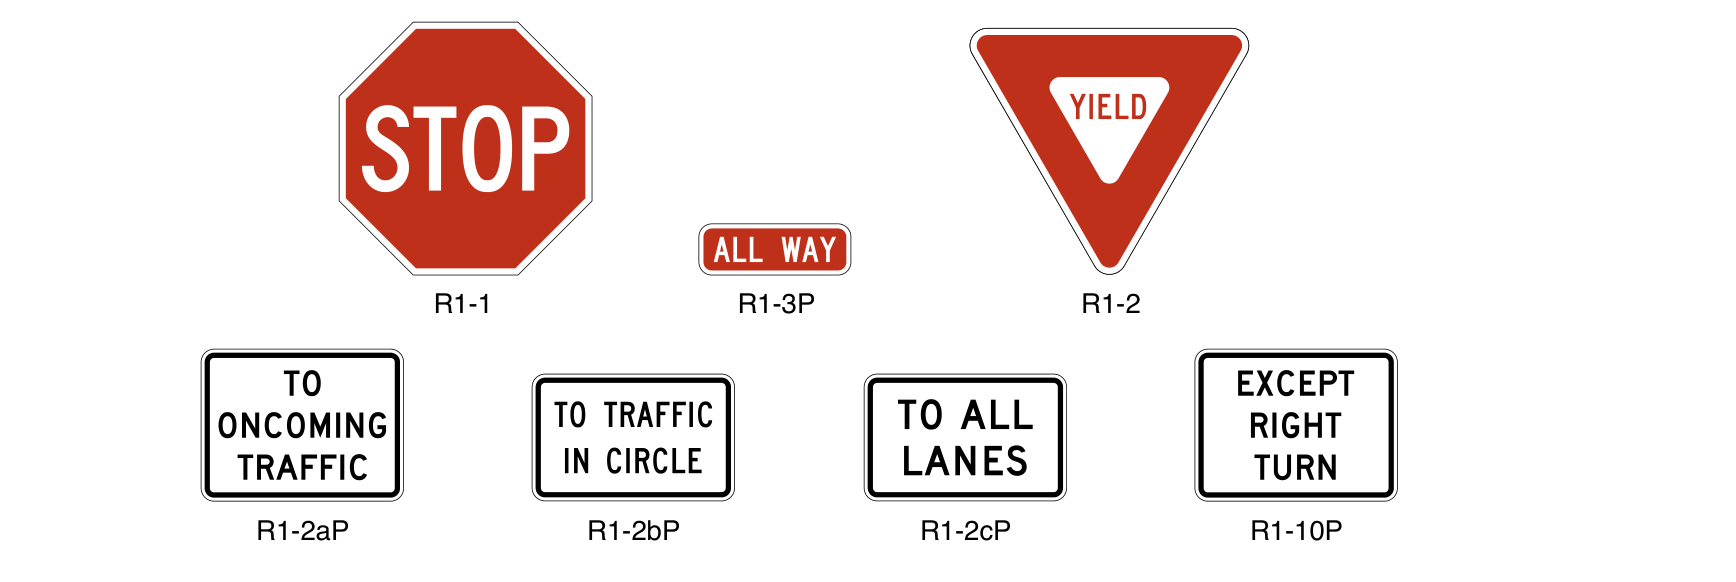

### Pages retrieved by ColPali

**[Page 1]** p.158 (score=17.898)

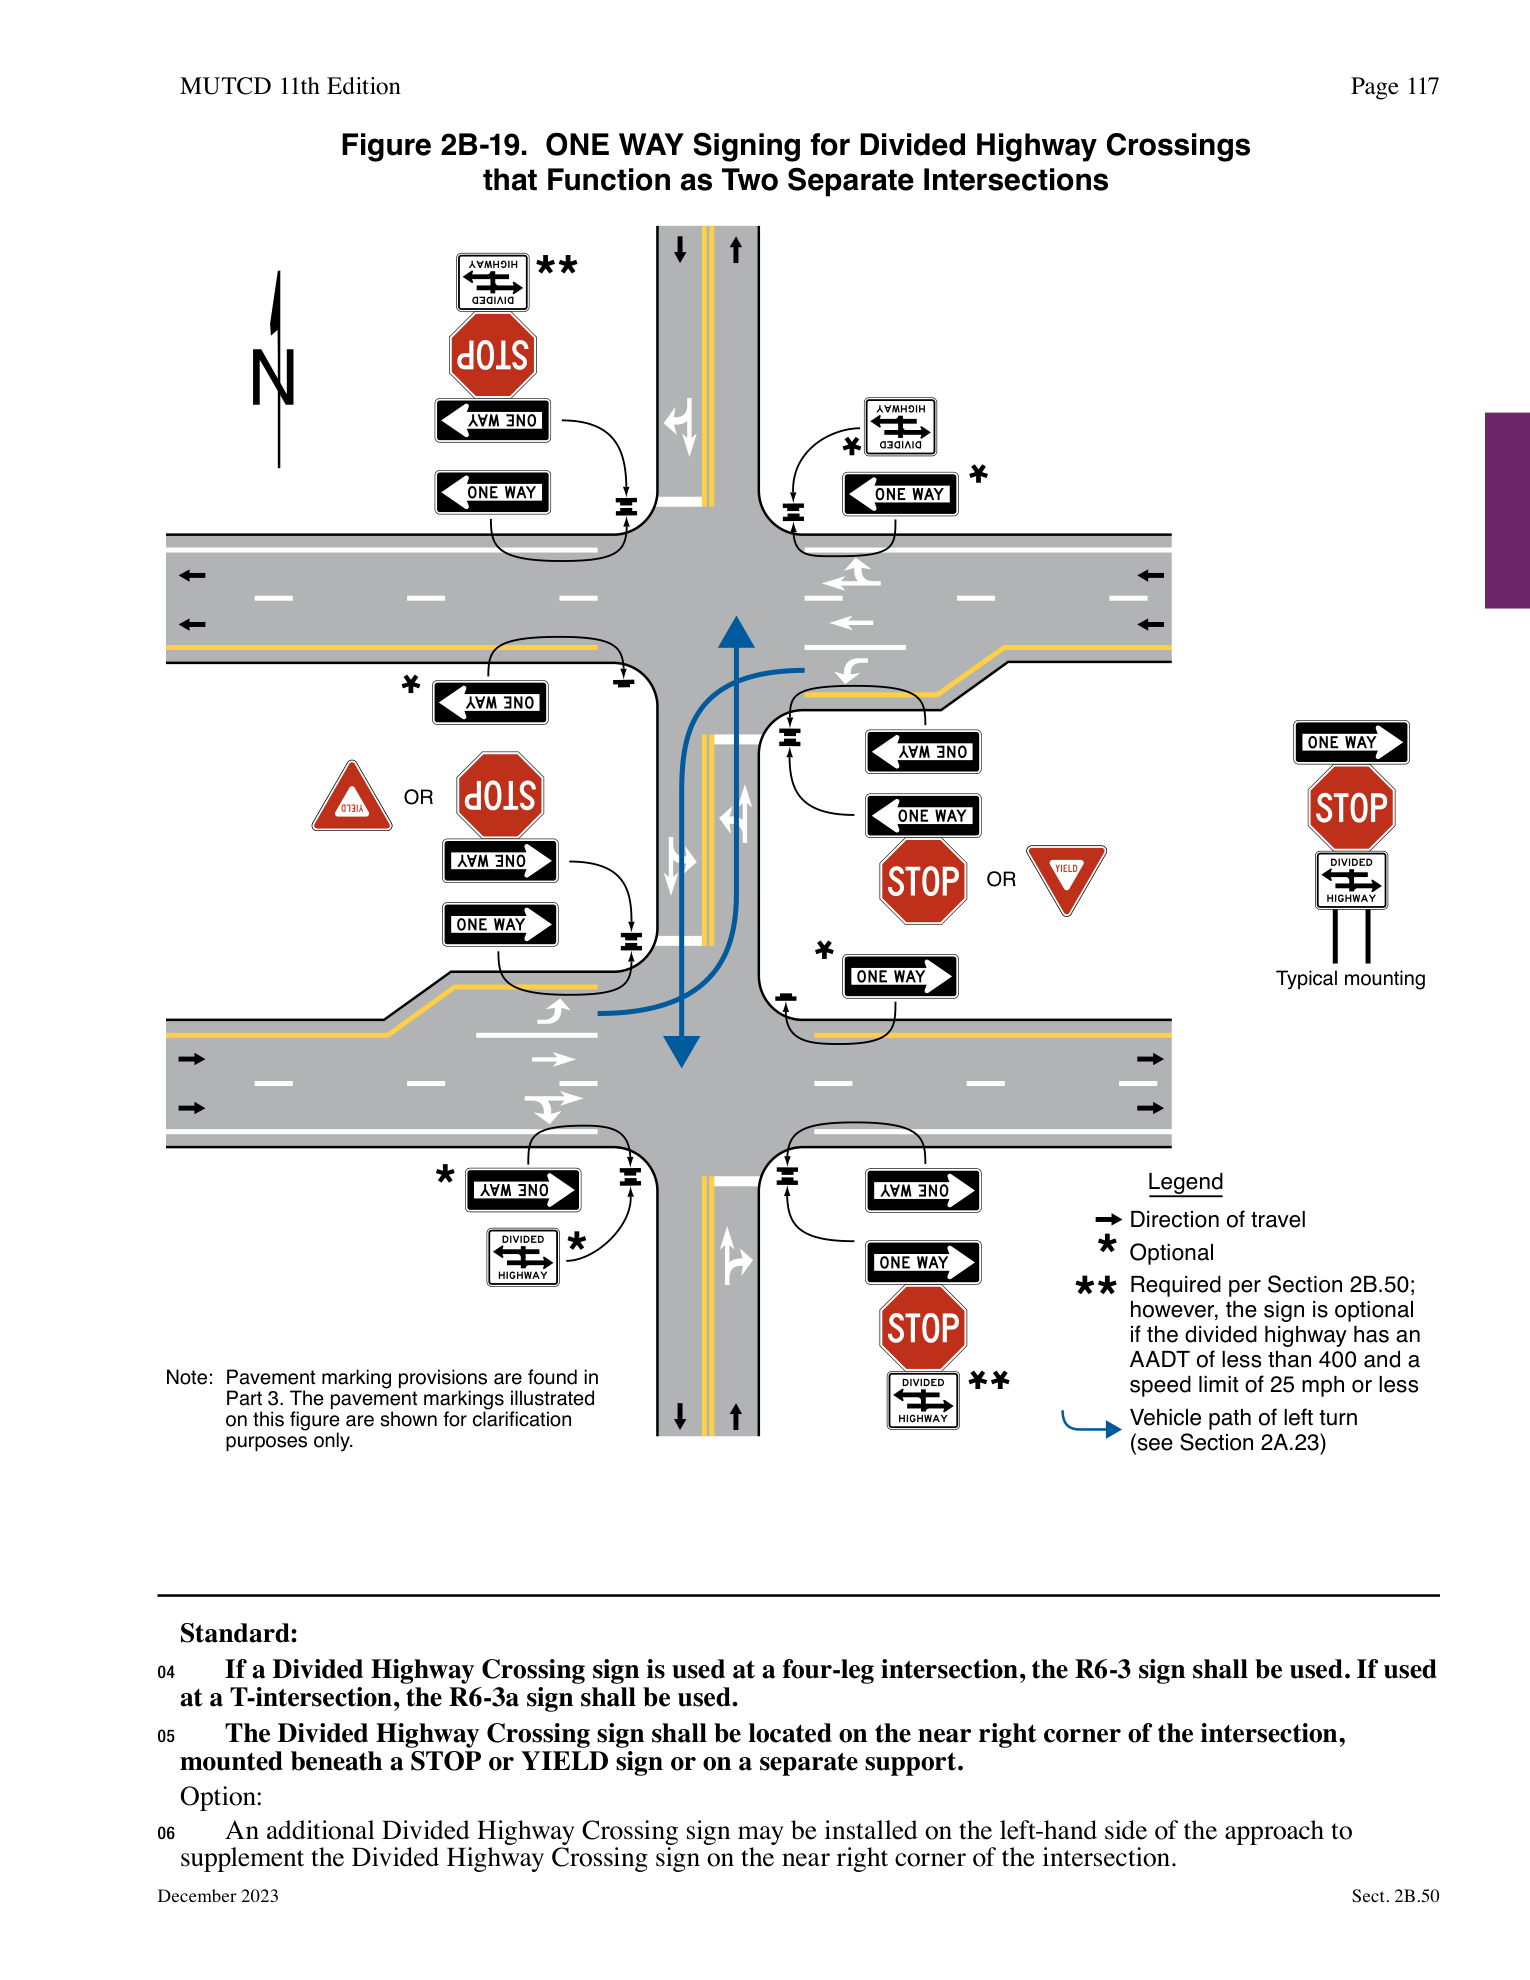

**[Page 2]** p.778 (score=17.612)

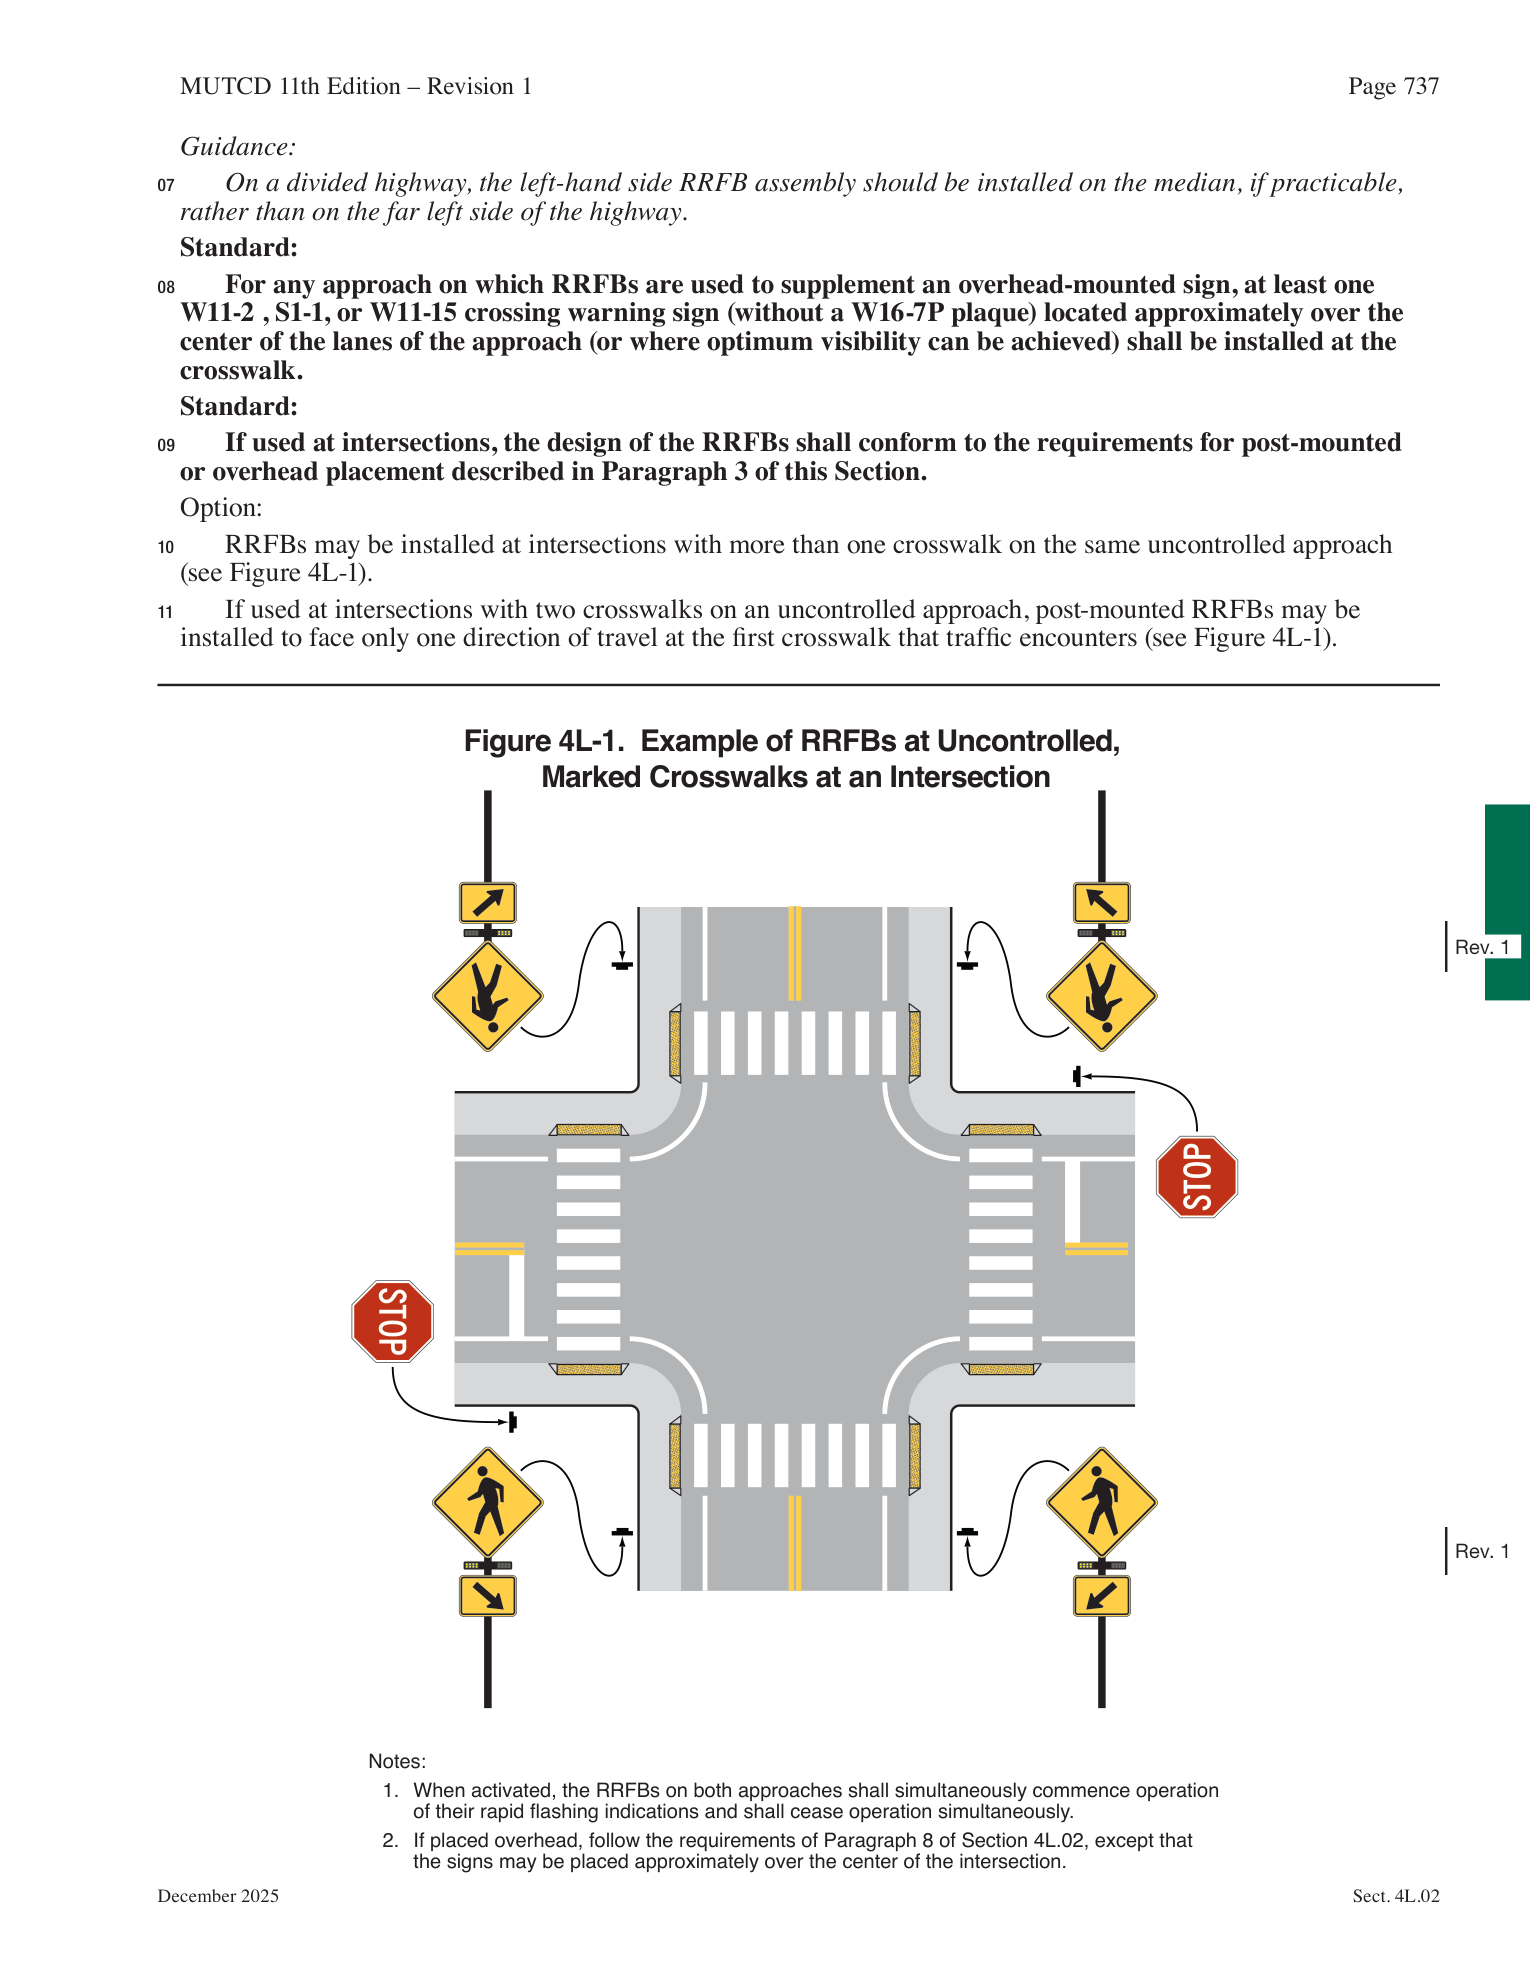

**[Page 3]** p.119 (score=17.383)

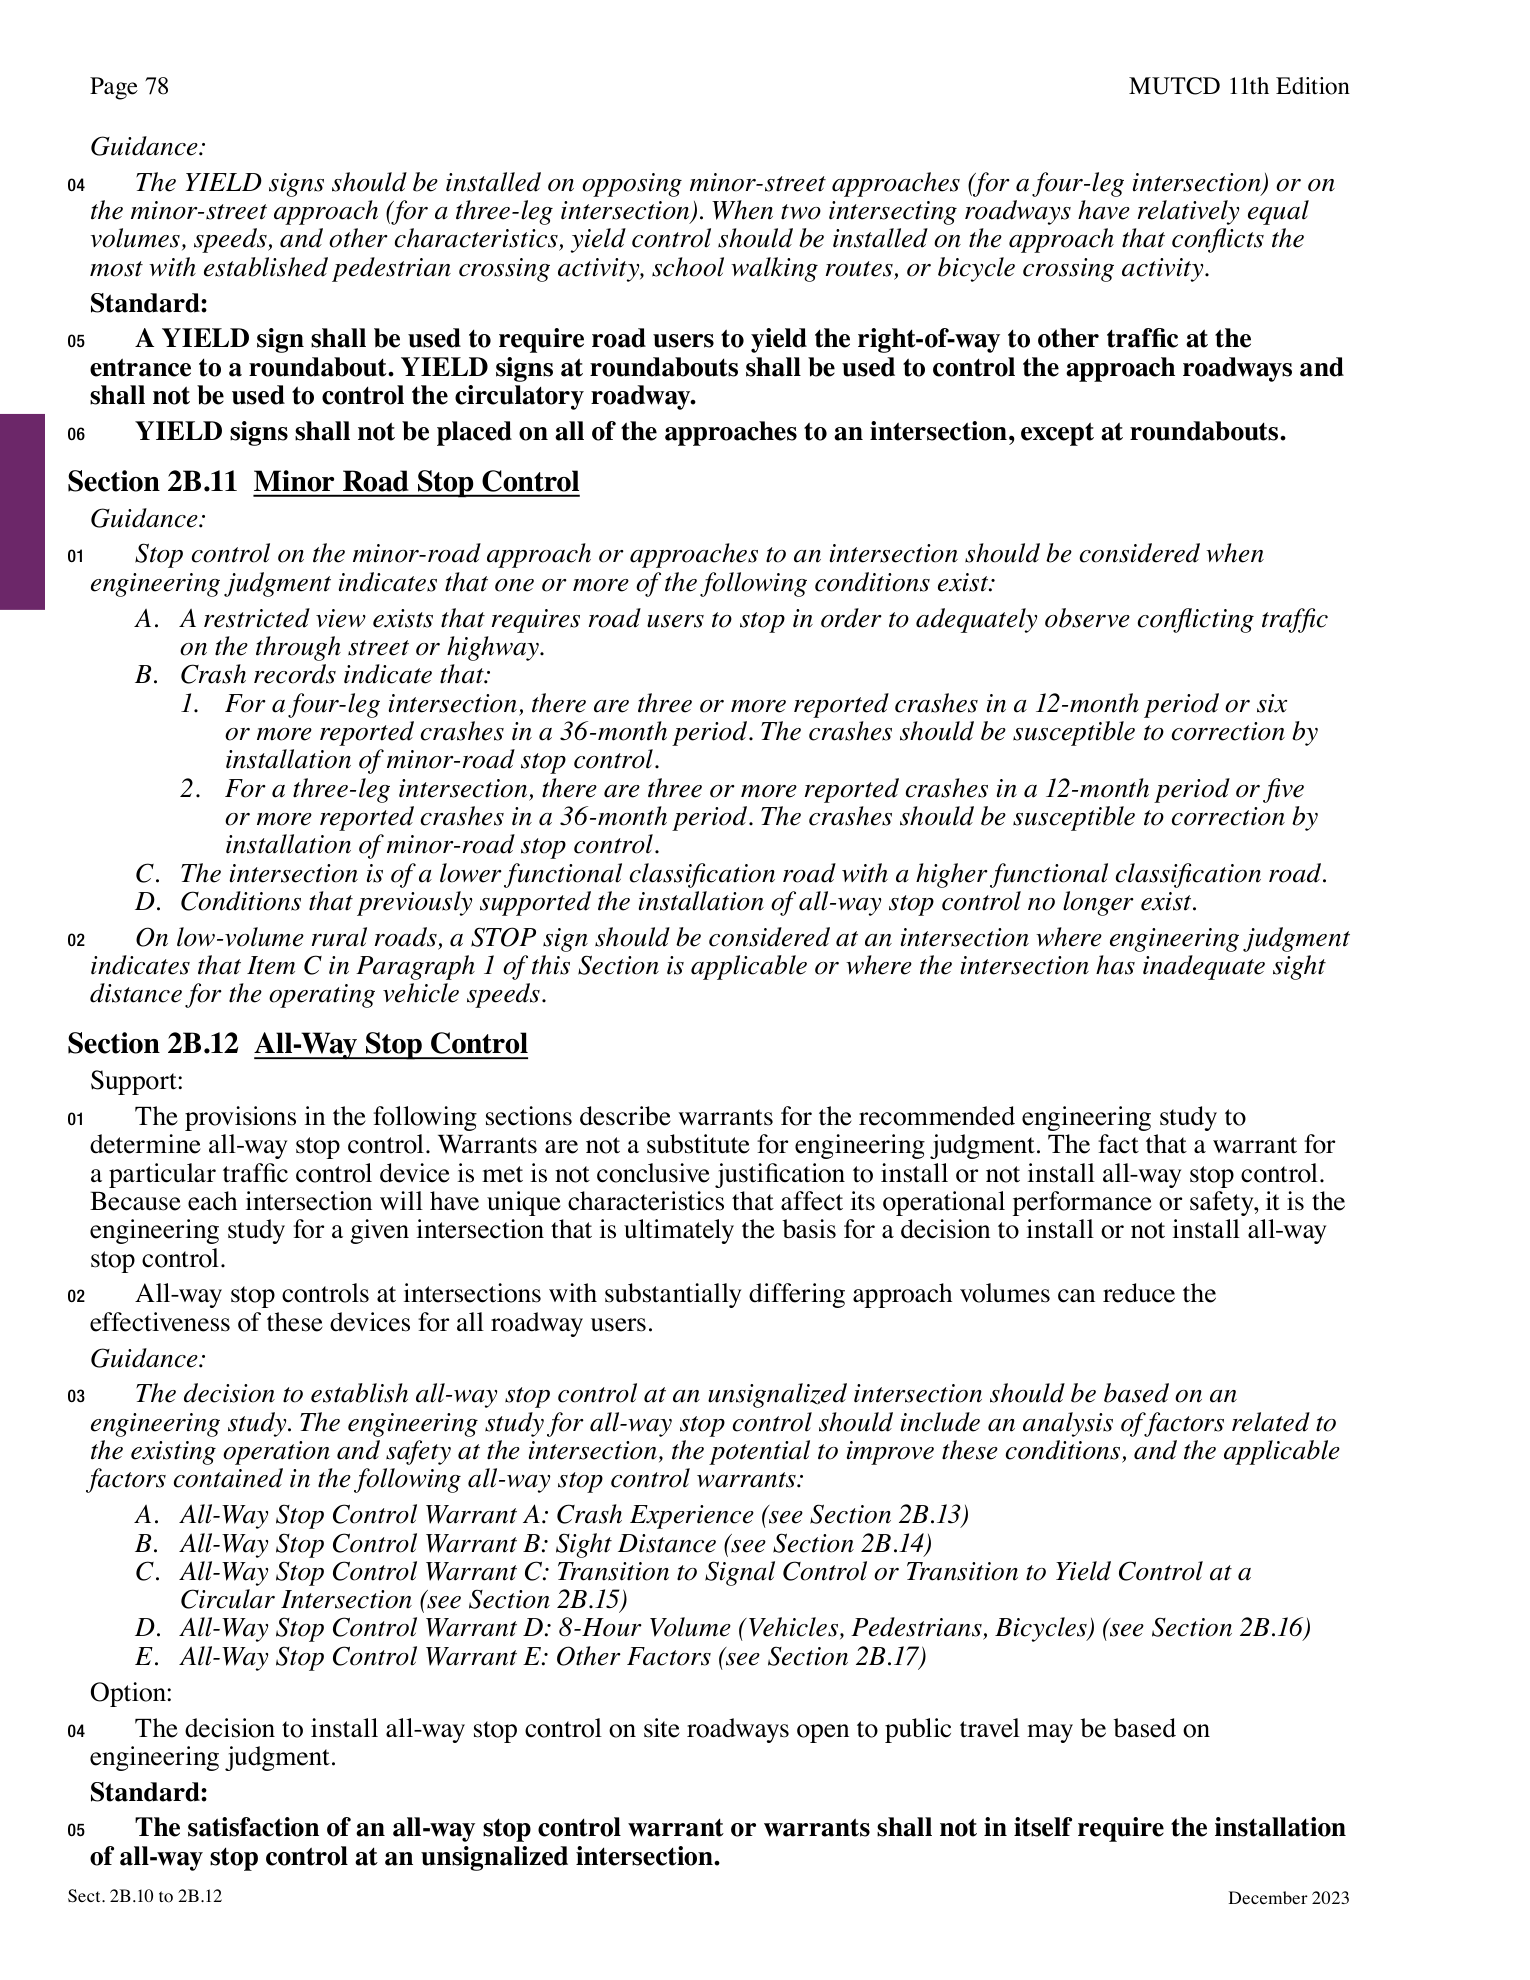

**[Page 4]** p.115 (score=17.355)

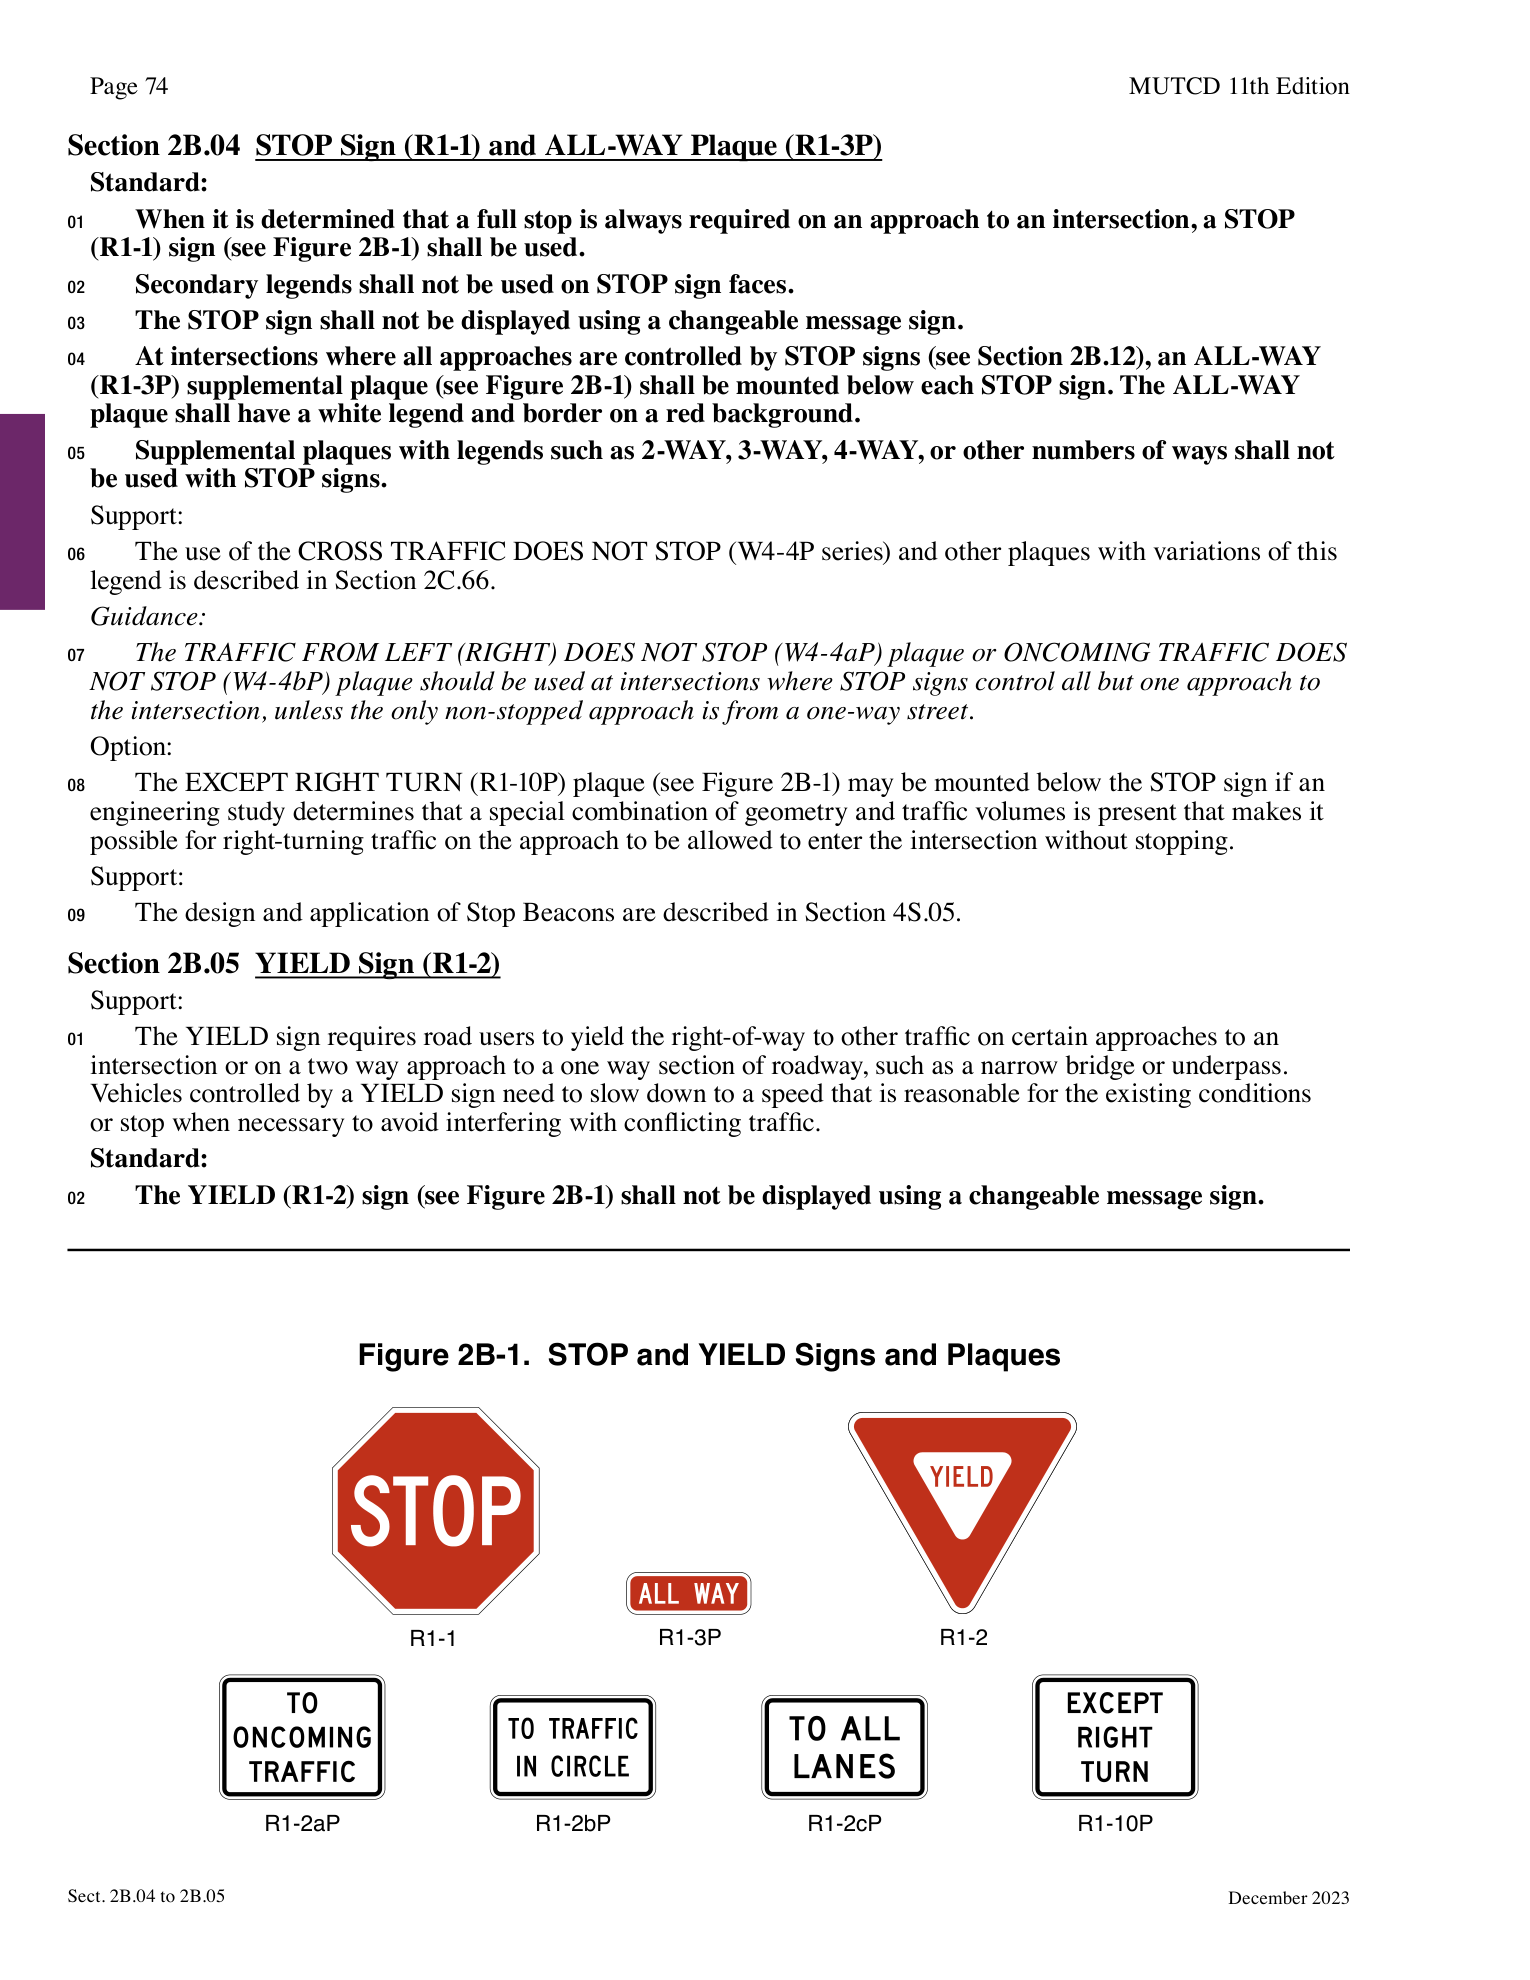

In [11]:
from mrag.ask import ask

_ = ask("What is required when installing a STOP sign at an all-way stop intersection?")


In [ ]:
_ = ask("Explain Figure 2B-1 and the plaques it shows", show_scores=True)


In [ ]:
_ = ask("What does MUTCD say about pedestrian hybrid beacons?", show_text=True)


# v4 router smoke test: a definitional question should retrieve NO figures.
_ = ask("What does 'shall' mean in the MUTCD?", show_scores=True)
# check the printed debug: figure_router.needs_figures should be False


## 4. Inspect the knowledge graph

In [8]:
kg = pipeline.kg
print(kg.g.number_of_nodes(), "nodes,", kg.g.number_of_edges(), "edges")


8240 nodes, 18245 edges


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 44.8 MB/s eta 0:00:00
KG loaded: 8240 nodes, 18245 edges
[visualize_kg] view='summary' target=None n_hops=1 paper=False
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_summary.png


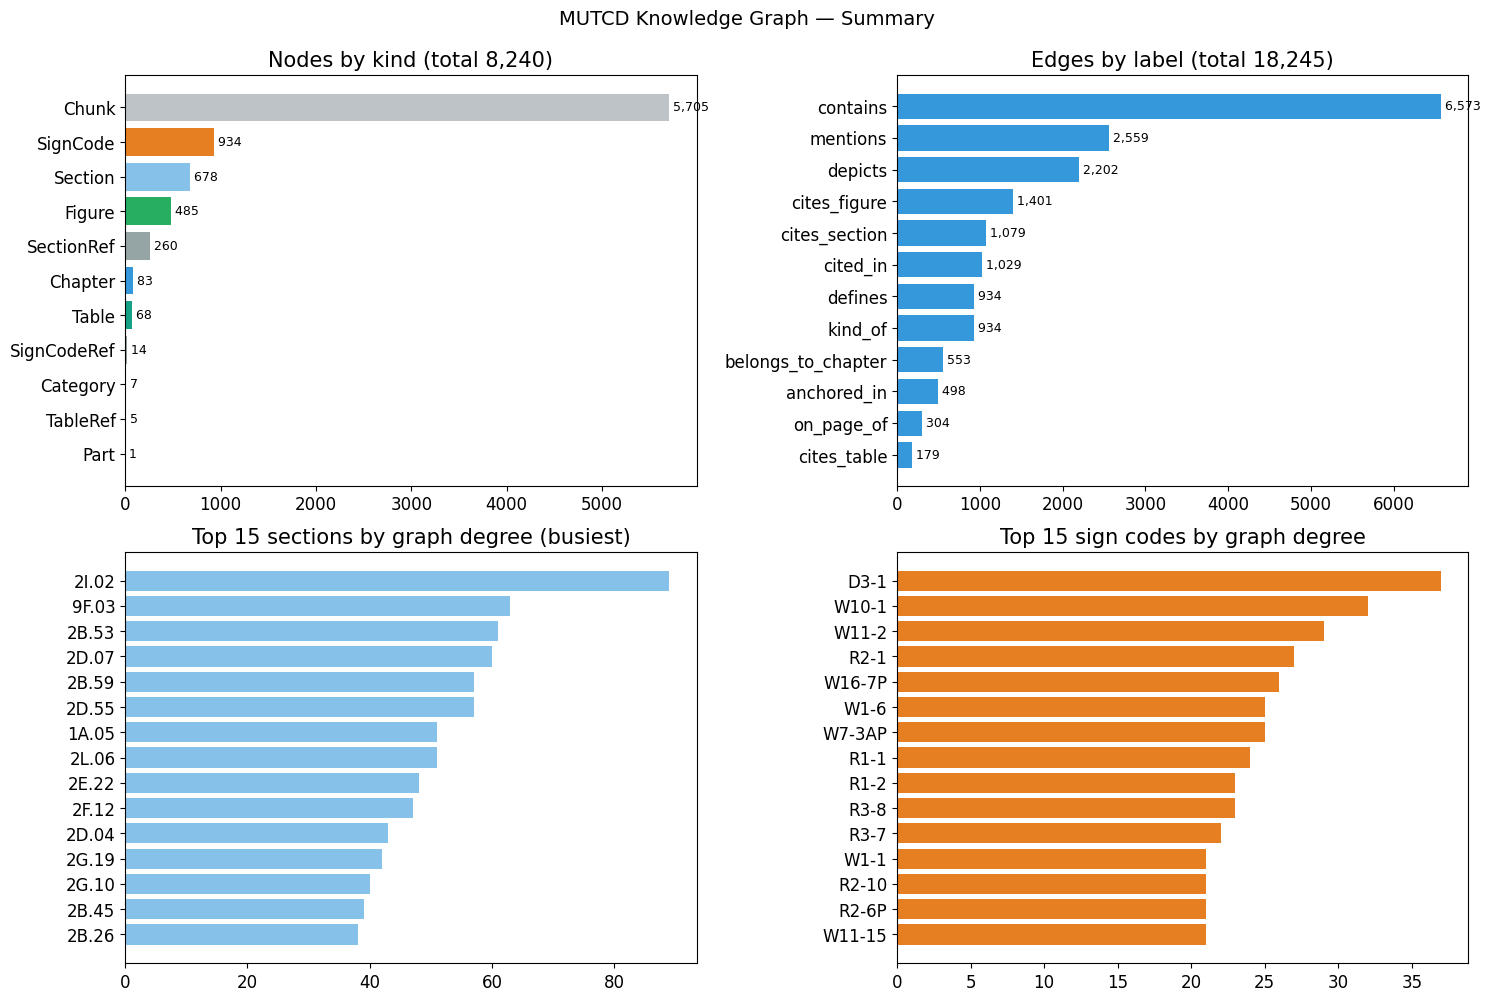

[visualize_kg] view='overview' target=None n_hops=1 paper=False
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_overview.html


[visualize_kg] view='section' target='2B.05' n_hops=1 paper=False
  Seeds (1): section:2B.05
  Node counts by kind: Chapter=1, Chunk=3, Figure=1, Section=1, SignCode=1
  Rendering subgraph: 7 nodes, 11 edges
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_section_2B.05.html


[visualize_kg] view='signcode' target='R1-1' n_hops=1 paper=False
  Seeds (1): signcode:R1-1
  Node counts by kind: Category=1, Chunk=13, Figure=4, Section=1, SignCode=1, Table=5
  Rendering subgraph: 25 nodes, 39 edges
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_signcode_R1-1.html


In [13]:
# =============================================================================
# Knowledge graph visualization — three views, one dispatcher
#
#   visualize_kg("overview")                                # static sankey
#   visualize_kg("summary")                                 # dashboard PNG
#   visualize_kg("section",  "2B.05")                       # interactive HTML
#   visualize_kg("signcode", "R1-1")
#   visualize_kg("question", "How are STOP signs installed?")
#
# All outputs saved to /content/drive/MyDrive/MRAG/kg_viz/
# =============================================================================
!pip install -q pyvis plotly

import re, shutil
from pathlib import Path
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go
from pyvis.network import Network
from IPython.display import IFrame, display, Image as IPImage

from mrag.config import CFG
from mrag.kg     import KG, read as kg_read

# ---------- output paths ------------------------------------------------------
LOCAL_VIZ_DIR = Path("/content/kg_viz")
DRIVE_VIZ_DIR = CFG.base_dir / "kg_viz"
LOCAL_VIZ_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_VIZ_DIR.mkdir(parents=True, exist_ok=True)

def _save_both(local_path: Path) -> Path:
    """Copy a freshly-written local file to Drive and return the Drive path."""
    drive_path = DRIVE_VIZ_DIR / local_path.name
    shutil.copy2(local_path, drive_path)
    print(f"  saved -> {drive_path}")
    return drive_path

# ---------- load KG once ------------------------------------------------------
_KG = KG(kg_read(CFG.graph_pickle))
print(f"KG loaded: {_KG.g.number_of_nodes()} nodes, {_KG.g.number_of_edges()} edges")

# ---------- color scheme by node kind -----------------------------------------
KIND_COLOR = {
    "Part":      "#1f3a93",   # deep blue
    "Chapter":   "#3498db",   # blue
    "Section":   "#85c1e9",   # light blue
    "Chunk":     "#bdc3c7",   # gray
    "Figure":    "#27ae60",   # green
    "Table":     "#16a085",   # teal
    "SignCode":  "#e67e22",   # orange
    "Category":  "#8e44ad",   # purple
}
KIND_DEFAULT = "#95a5a6"

# =============================================================================
# View 1: overview — Part → Chapter → Section sankey (plotly, interactive HTML)
# =============================================================================
def _view_overview():
    g = _KG.g
    parts    = [n for n, d in g.nodes(data=True) if d.get("kind") == "Part"]
    chapters = [n for n, d in g.nodes(data=True) if d.get("kind") == "Chapter"]
    sections = [n for n, d in g.nodes(data=True) if d.get("kind") == "Section"]

    # Build sankey nodes / links: Part(0..P) | Chapter(P..P+C) | one "Sections" tail per chapter
    labels, colors = [], []
    idx = {}
    for p in parts:
        idx[p] = len(labels); labels.append(g.nodes[p].get("title", p)); colors.append(KIND_COLOR["Part"])
    for c in chapters:
        idx[c] = len(labels); labels.append(g.nodes[c].get("title", c)); colors.append(KIND_COLOR["Chapter"])

    sect_count_per_chapter = Counter()
    for s in sections:
        chap_title = g.nodes[s].get("chapter")
        sect_count_per_chapter[chap_title] += 1

    src, tgt, val, link_color = [], [], [], []
    # Part -> Chapter
    for c in chapters:
        chap_part = g.nodes[c].get("part")
        # Find part node by title
        for p in parts:
            if g.nodes[p].get("title") == chap_part:
                src.append(idx[p]); tgt.append(idx[c])
                val.append(max(1, sect_count_per_chapter[g.nodes[c].get("title")]))
                link_color.append("rgba(52,152,219,0.3)")
                break

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=labels, color=colors, pad=10, thickness=14,
                  line=dict(color="white", width=0.5)),
        link=dict(source=src, target=tgt, value=val, color=link_color),
    ))
    fig.update_layout(
        title="MUTCD KG — Parts → Chapters (link width = #Sections in chapter)",
        font=dict(size=12),
        height=max(600, 25 * len(chapters)),
        margin=dict(l=10, r=10, t=50, b=10),
    )
    out = LOCAL_VIZ_DIR / "kg_overview.html"
    fig.write_html(out, include_plotlyjs="cdn")
    _save_both(out)
    fig.show()

# =============================================================================
# View 2: summary — counts dashboard (matplotlib PNG)
# =============================================================================
def _view_summary():
    plt.rcParams.update({
        "font.size":       9,   # base font
        "axes.titlesize":  15,
        "axes.labelsize":  13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })
    g = _KG.g
    kind_counts = Counter(d.get("kind") for _, d in g.nodes(data=True))
    edge_counts = Counter(d.get("label") for *_ , d in g.edges(data=True))

    # Top-degree sections (busiest in the graph)
    sec_deg = []
    for n, d in g.nodes(data=True):
        if d.get("kind") == "Section":
            sec_deg.append((d.get("id", n), g.degree(n)))
    sec_deg.sort(key=lambda x: x[1], reverse=True)
    top_sections = sec_deg[:15]

    # Top sign codes by degree (most-connected codes)
    sc_deg = []
    for n, d in g.nodes(data=True):
        if d.get("kind") == "SignCode":
            sc_deg.append((d.get("id", n), g.degree(n)))
    sc_deg.sort(key=lambda x: x[1], reverse=True)
    top_codes = sc_deg[:15]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("MUTCD Knowledge Graph — Summary", fontsize=14, y=0.995)

    # (0,0) node kinds
    ax = axes[0, 0]
    names = [k for k, _ in kind_counts.most_common()]
    vals  = [kind_counts[k] for k in names]
    cols  = [KIND_COLOR.get(k, KIND_DEFAULT) for k in names]
    ax.barh(names, vals, color=cols)
    ax.set_title(f"Nodes by kind (total {g.number_of_nodes():,})")
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    ax.invert_yaxis()

    # (0,1) edge labels
    ax = axes[0, 1]
    names = [k for k, _ in edge_counts.most_common()]
    vals  = [edge_counts[k] for k in names]
    ax.barh(names, vals, color="#3498db")
    ax.set_title(f"Edges by label (total {g.number_of_edges():,})")
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    ax.invert_yaxis()

    # (1,0) top 15 sections by degree
    ax = axes[1, 0]
    names = [s for s, _ in top_sections]
    vals  = [d for _, d in top_sections]
    ax.barh(names, vals, color=KIND_COLOR["Section"])
    ax.set_title("Top 15 sections by graph degree (busiest)")
    ax.invert_yaxis()

    # (1,1) top 15 sign codes by degree
    ax = axes[1, 1]
    names = [c for c, _ in top_codes]
    vals  = [d for _, d in top_codes]
    ax.barh(names, vals, color=KIND_COLOR["SignCode"])
    ax.set_title("Top 15 sign codes by graph degree")
    ax.invert_yaxis()

    plt.tight_layout()
    out = LOCAL_VIZ_DIR / "kg_summary.png"
    fig.savefig(out, dpi=140, bbox_inches="tight")
    _save_both(out)
    plt.show()

# =============================================================================
# View 3: neighborhood — interactive PyVis HTML around a target / question
# =============================================================================
def _resolve_target(kind: str, target: str) -> set[str]:
    """Return the set of seed node IDs for a given kind + target."""
    seeds: set[str] = set()
    if kind == "section":
        n = _KG.section(target)
        if n: seeds.add(n)
    elif kind == "signcode":
        n = _KG.sign(target)
        if n: seeds.add(n)
    elif kind == "question":
        # Use the same entity-extraction the retriever uses.
        seeds = _KG.query_entities(target)
    return seeds

def _short_label(g, node: str, max_len: int = 28) -> str:
    """Human-readable label, kind-aware, truncated for visual neatness."""
    d = g.nodes[node]
    k = d.get("kind", "")
    if k == "Section":
        sid = d.get("id", node)
        title = (d.get("title") or "")[:max_len]
        return f"§{sid}\n{title}" if title else f"§{sid}"
    if k == "Chunk":
        ct = d.get("content_type", "")
        sec = d.get("section", "")
        return f"{ct} §{sec}.{d.get('ordinal','?')}"
    if k in ("Figure", "Table"):
        return d.get("id", node)
    if k == "SignCode":
        return d.get("id", node)
    if k == "Category":
        return d.get("id", node)
    if k in ("Part", "Chapter"):
        return (d.get("title") or node)[:max_len]
    return node[:max_len]

def _view_neighborhood(kind: str, target: str, n_hops: int = 1,
                       max_nodes: int = 200):
    g = _KG.g
    seeds = _resolve_target(kind, target)
    if not seeds:
        print(f"  No matching nodes for {kind}={target!r}. Try a different value.")
        print(f"  Tip: 'section' wants something like '2B.05', 'signcode' like 'R1-1'.")
        return

    print(f"  Seeds ({len(seeds)}): {', '.join(sorted(seeds))[:200]}")

    # Expand n-hop neighborhood (union over seeds)
    nodes: set[str] = set()
    for s in seeds:
        nodes |= _KG.neighbors(s, n_hops=n_hops)

    if len(nodes) > max_nodes:
        print(f"  Neighborhood has {len(nodes)} nodes (cap {max_nodes}). "
              f"Trimming chunks first to keep it readable.")
        keep_high_prio = {n for n in nodes
                          if g.nodes[n].get("kind") in
                          ("Part", "Chapter", "Section", "Figure", "Table",
                           "SignCode", "Category")}
        chunks_in = sorted(n for n in nodes
                           if g.nodes[n].get("kind") == "Chunk")
        room = max_nodes - len(keep_high_prio)
        if room < 0: room = 0
        nodes = keep_high_prio | set(chunks_in[:room])

    sub = g.subgraph(nodes).copy()
    from collections import Counter
    _kind_counts = Counter(d.get("kind", "?") for _, d in sub.nodes(data=True))
    print("  Node counts by kind: "
          + ", ".join(f"{k}={v}" for k, v in sorted(_kind_counts.items())))
    print(f"  Rendering subgraph: {sub.number_of_nodes()} nodes, "
          f"{sub.number_of_edges()} edges")

    # Build PyVis network
    net = Network(height="650px", width="100%", directed=True,
                  notebook=False, bgcolor="#ffffff", font_color="#222")
    net.barnes_hut(gravity=-3000, central_gravity=0.2, spring_length=120)
    net.set_options("""
    {
      "nodes": { "font": { "size": 9, "face": "Arial", "bold": false } },
      "edges": { "font": { "size": 10, "align": "middle" },
                 "smooth": { "type": "dynamic" } }
    }
    """)

    for n in sub.nodes:
        d = sub.nodes[n]
        k = d.get("kind", "")
        color = KIND_COLOR.get(k, KIND_DEFAULT)
        size  = 32 if n in seeds else (
                22 if k in ("Part", "Chapter")     else
                18 if k in ("Section", "Figure", "Table", "SignCode") else
                10)
        if n in seeds:
            border = "#e74c3c"   # red ring around seed nodes
        else:
            border = color
        # Tooltip = full attribute dump
        tip_lines = [f"<b>{k}</b>"]
        for tk in ("id", "title", "page_printed", "section", "content_type",
                   "caption", "category", "canonical_name", "modal_verbs"):
            if tk in d and d[tk] not in (None, "", (), []):
                tip_lines.append(f"{tk}: {d[tk]}")
        net.add_node(n, label=_short_label(sub, n), color=color,
                     borderWidth=4 if n in seeds else 1, borderWidthSelected=6,
                     size=size, title="<br>".join(tip_lines))

    for u, v, ed in sub.edges(data=True):
        net.add_edge(u, v, title=ed.get("label", ""), label=ed.get("label", ""),
                     arrows="to", color={"opacity": 0.45})

# ---- Legend tuning ----------------------------------------------------
    LEGEND_X       = -550   # more negative = further left
    LEGEND_Y_TOP   = -150    # more negative = higher up
    LEGEND_SPACING = 45      # vertical gap between entries
    LEGEND_FONT = {          # applies to legend box labels only
        "size":   18,
        "face":   "Arial",
        "color":  "#969393",   # text color (dark grey / near-black)
        "bold":   True,
        "strokeWidth": 0,
    }
    # -----------------------------------------------------------------------
    for i, (k, col) in enumerate(KIND_COLOR.items()):
        net.add_node(
            f"_legend_{k}", label=k, color=col, shape="box",
            x=LEGEND_X, y=LEGEND_Y_TOP + i * LEGEND_SPACING,
            fixed=True, physics=False, size=18,
            font=LEGEND_FONT,
        )

    safe_target = re.sub(r"[^A-Za-z0-9._-]+", "_", target)[:40]
    out = LOCAL_VIZ_DIR / f"kg_{kind}_{safe_target}.html"
    net.write_html(str(out), notebook=False)
    _save_both(out)
    display(IFrame(str(out), width="100%", height=680))
# =============================================================================
# View 3B: neighborhood — PAPER-QUALITY static matplotlib figure (PDF + PNG)
# =============================================================================
def _view_neighborhood_paper(
    kind: str, target: str,
    n_hops: int = 1,
    include_chunks: bool = False,     # False = cleaner paper figure
    layout: str = "kamada_kawai",     # "kamada_kawai" | "spring" | "shell"
    figsize=(11, 9),
    dpi: int = 300,
    label_fontsize: int = 11,
    edge_label_fontsize: int = 9,
    show_edge_labels: bool = False,   # off by default; edges colored instead
    seed: int = 42,
    title: str | None = None,
    caption: str | None = None,
):
    """Deterministic, publication-quality neighborhood figure.

    Differences from the interactive PyVis version:
      - deterministic layout (Kamada-Kawai) so the figure is reproducible
      - chunks aggregated / hidden by default (include_chunks=True to keep them)
      - edge TYPE encoded by COLOR, not by text label (text off by default)
      - proper matplotlib legend (nodes + edge types) in a bordered box
      - vector PDF + high-DPI PNG for the paper

    Recommended calls:
        _view_neighborhood_paper("signcode", "R1-1",  n_hops=1)
        _view_neighborhood_paper("section",  "2B.05", n_hops=1)
    """
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D

    g = _KG.g
    seeds = _resolve_target(kind, target)
    if not seeds:
        print(f"  No matching nodes for {kind}={target!r}."); return

    nodes: set[str] = set()
    for s in seeds:
        nodes |= _KG.neighbors(s, n_hops=n_hops)

    if not include_chunks:
        nodes = {n for n in nodes if g.nodes[n].get("kind") != "Chunk"}
    sub = g.subgraph(nodes).copy()

    if sub.number_of_nodes() == 0:
        print("  Empty subgraph after filtering — try include_chunks=True.")
        return

    print(f"  Paper subgraph: {sub.number_of_nodes()} nodes, "
          f"{sub.number_of_edges()} edges "
          f"(chunks {'kept' if include_chunks else 'hidden'})")

    # --- layout ---
    if layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(sub)
    elif layout == "shell":
        # seed(s) at center, everything else on outer ring
        shell = [list(seeds & set(sub.nodes)), [n for n in sub.nodes if n not in seeds]]
        pos = nx.shell_layout(sub, shell)
    else:
        pos = nx.spring_layout(sub, seed=seed, k=1.2 / (sub.number_of_nodes() ** 0.5))

    # --- edge coloring by relationship type ---
    EDGE_COLORS = {
        "contains":     "#95a5a6",   # gray, structural
        "cites_figure": "#27ae60",   # green
        "cites_table":  "#16a085",   # teal
        "depicts":      "#e67e22",   # orange
        "defines":      "#8e44ad",   # purple
        "mentions":     "#bdc3c7",   # light gray (many of these — recessive)
        "kind_of":      "#7f8c8d",   # slate
    }
    EDGE_DEFAULT = "#cccccc"

    # --- node styling ---
    def _node_size(n) -> int:
        k = sub.nodes[n].get("kind", "")
        if n in seeds:                                             return 2400
        if k in ("Part",):                                         return 1300
        if k in ("Chapter",):                                      return 1100
        if k in ("Section",):                                      return 900
        if k in ("Figure", "Table", "SignCode", "Category"):       return 700
        return 250

    node_colors = [KIND_COLOR.get(sub.nodes[n].get("kind"), KIND_DEFAULT) for n in sub.nodes]
    node_sizes  = [_node_size(n) for n in sub.nodes]
    edge_colors = [EDGE_COLORS.get(ed.get("label"), EDGE_DEFAULT)
                   for _, _, ed in sub.edges(data=True)]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")

    nx.draw_networkx_edges(
        sub, pos, ax=ax,
        edge_color=edge_colors, alpha=0.75, width=1.4,
        arrows=True, arrowstyle="-|>", arrowsize=14,
        connectionstyle="arc3,rad=0.06",
        node_size=node_sizes,   # so arrowheads stop at node border, not center
    )
    # Seed nodes get a distinctive red ring
    seed_list = [n for n in sub.nodes if n in seeds]
    other_list = [n for n in sub.nodes if n not in seeds]
    nx.draw_networkx_nodes(
        sub, pos, ax=ax, nodelist=other_list,
        node_color=[KIND_COLOR.get(sub.nodes[n].get("kind"), KIND_DEFAULT) for n in other_list],
        node_size=[_node_size(n) for n in other_list],
        edgecolors="#333333", linewidths=0.8,
    )
    nx.draw_networkx_nodes(
        sub, pos, ax=ax, nodelist=seed_list,
        node_color=[KIND_COLOR.get(sub.nodes[n].get("kind"), KIND_DEFAULT) for n in seed_list],
        node_size=[_node_size(n) for n in seed_list],
        edgecolors="#c0392b", linewidths=2.5,
    )

    # --- labels ---
    def _paper_label(n) -> str:
        d = sub.nodes[n]; k = d.get("kind", "")
        if k == "Section":                       return f"§{d.get('id', n)}"
        if k in ("Figure", "Table", "SignCode"): return d.get("id", n)
        if k == "Category":                      return d.get("id", n)
        if k in ("Part", "Chapter"):
            return (d.get("title") or n).split("—")[0].strip()[:24]
        if k == "Chunk":
            ct = d.get("content_type", "")[:1]
            sec = d.get("section", "")
            return f"{ct}§{sec}"
        return n[:18]

    labels = {n: _paper_label(n) for n in sub.nodes}
    nx.draw_networkx_labels(
        sub, pos, labels=labels, ax=ax,
        font_size=label_fontsize, font_weight="normal",
        font_family="DejaVu Sans",
    )

    if show_edge_labels:
        edge_labels = {(u, v): ed.get("label", "") for u, v, ed in sub.edges(data=True)}
        nx.draw_networkx_edge_labels(
            sub, pos, edge_labels=edge_labels, ax=ax,
            font_size=edge_label_fontsize, font_color="#555",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
        )

    # --- title / caption ---
    if title is None:
        target_disp = target if kind != "question" else f"'{target[:40]}'"
        title = f"KG neighborhood of {kind}={target_disp} ({n_hops}-hop)"
    ax.set_title(title, fontsize=14, fontweight="normal", pad=12)

    if caption is None:
        caption = (f"Node count: {sub.number_of_nodes()}   ·   "
                   f"Edge count: {sub.number_of_edges()}   ·   "
                   f"Layout: {layout}   ·   "
                   f"{'chunks aggregated' if not include_chunks else 'chunks shown'}")
    fig.text(0.5, 0.02, caption, ha="center", fontsize=9, color="#555", style="italic")

    # --- combined legend: node kinds present + edge types present ---
    kinds_present = {sub.nodes[n].get("kind", "") for n in sub.nodes}
    node_handles = [
        mpatches.Patch(facecolor=KIND_COLOR.get(k, KIND_DEFAULT),
                       edgecolor="#333", label=k)
        for k in KIND_COLOR if k in kinds_present
    ]
    edge_labels_present = {ed.get("label") for _, _, ed in sub.edges(data=True)}
    edge_handles = [
        Line2D([0], [0], color=EDGE_COLORS.get(l, EDGE_DEFAULT),
               lw=2, label=l)
        for l in EDGE_COLORS if l in edge_labels_present
    ]
    seed_handle = Line2D([0], [0], marker="o", color="none",
                         markerfacecolor="white", markeredgecolor="#c0392b",
                         markeredgewidth=2.5, markersize=14, label="seed node")
    leg = ax.legend(
        handles=[seed_handle] + node_handles + edge_handles,
        loc="upper left", bbox_to_anchor=(1.005, 1.0),
        frameon=True, framealpha=0.95, edgecolor="#888",
        fontsize=10, title="Legend", title_fontsize=11,
        borderpad=0.9, labelspacing=0.7, handlelength=1.8,
    )
    leg.get_frame().set_linewidth(0.6)

    ax.axis("off")
    plt.tight_layout(rect=[0, 0.03, 0.98, 0.98])

    safe_target = re.sub(r"[^A-Za-z0-9._-]+", "_", target)[:40]
    out_pdf = LOCAL_VIZ_DIR / f"kg_paper_{kind}_{safe_target}_{n_hops}h.pdf"
    out_png = LOCAL_VIZ_DIR / f"kg_paper_{kind}_{safe_target}_{n_hops}h.png"
    fig.savefig(out_pdf, dpi=dpi, bbox_inches="tight")
    fig.savefig(out_png, dpi=dpi, bbox_inches="tight")
    _save_both(out_pdf); _save_both(out_png)
    plt.show()

# =============================================================================
# Dispatcher
# =============================================================================
def visualize_kg(view: str = "overview", target: str | None = None,
                 n_hops: int = 1, max_nodes: int = 200,
                 paper: bool = False, **paper_kw) -> None:
    view = view.lower().strip()
    print(f"[visualize_kg] view={view!r} target={target!r} n_hops={n_hops} paper={paper}")
    if view == "overview":  _view_overview()
    elif view == "summary": _view_summary()
    elif view in ("section", "signcode", "question"):
        if not target: raise ValueError(f"view={view!r} requires a target")
        if paper:
            _view_neighborhood_paper(view, target, n_hops=n_hops, **paper_kw)
        else:
            _view_neighborhood(view, target, n_hops=n_hops, max_nodes=max_nodes)
    else:
        raise ValueError(f"Unknown view {view!r}.")

# =============================================================================
# Demo — run the four most useful views immediately
# =============================================================================
visualize_kg("summary")
visualize_kg("overview")
visualize_kg("section",  "2B.05",  n_hops=1)
visualize_kg("signcode", "R1-1",   n_hops=1)

In [14]:
def print_kg_counts():
    from collections import Counter
    counts = Counter(d.get("kind", "?") for _, d in _KG.g.nodes(data=True))
    print("Whole-KG node counts by kind:")
    for k in sorted(counts, key=lambda x: -counts[x]):
        print(f"  {k:12s} {counts[k]:>6,}")
    print(f"  {'TOTAL':12s} {sum(counts.values()):>6,}")
    print(f"  edges       {_KG.g.number_of_edges():>6,}")

print_kg_counts()

Whole-KG node counts by kind:
  Chunk         5,705
  SignCode        934
  Section         678
  Figure          485
  SectionRef      260
  Chapter          83
  Table            68
  SignCodeRef      14
  Category          7
  TableRef          5
  Part              1
  TOTAL         8,240
  edges       18,245


[visualize_kg] view='signcode' target='R1-1' n_hops=1 paper=True
  Paper subgraph: 12 nodes, 14 edges (chunks hidden)
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.pdf
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.png


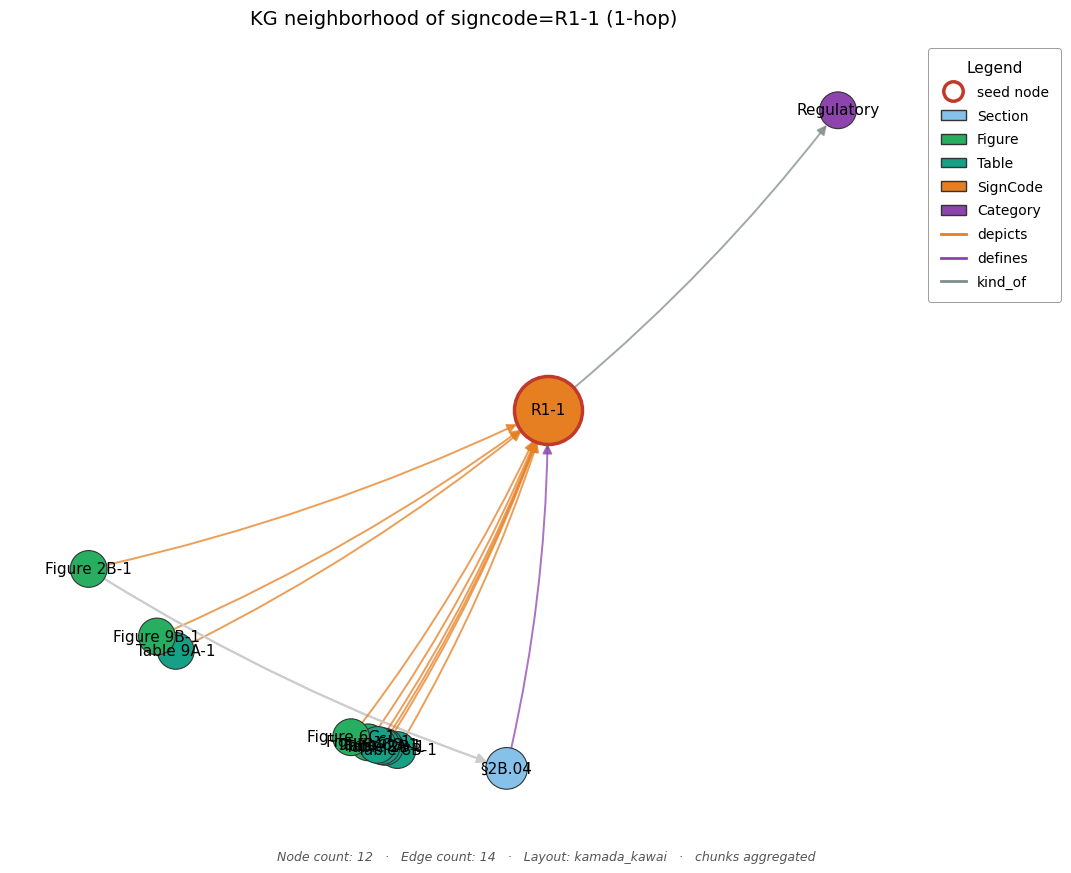

[visualize_kg] view='signcode' target='R1-1' n_hops=1 paper=True
  Paper subgraph: 25 nodes, 39 edges (chunks kept)
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.pdf
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.png


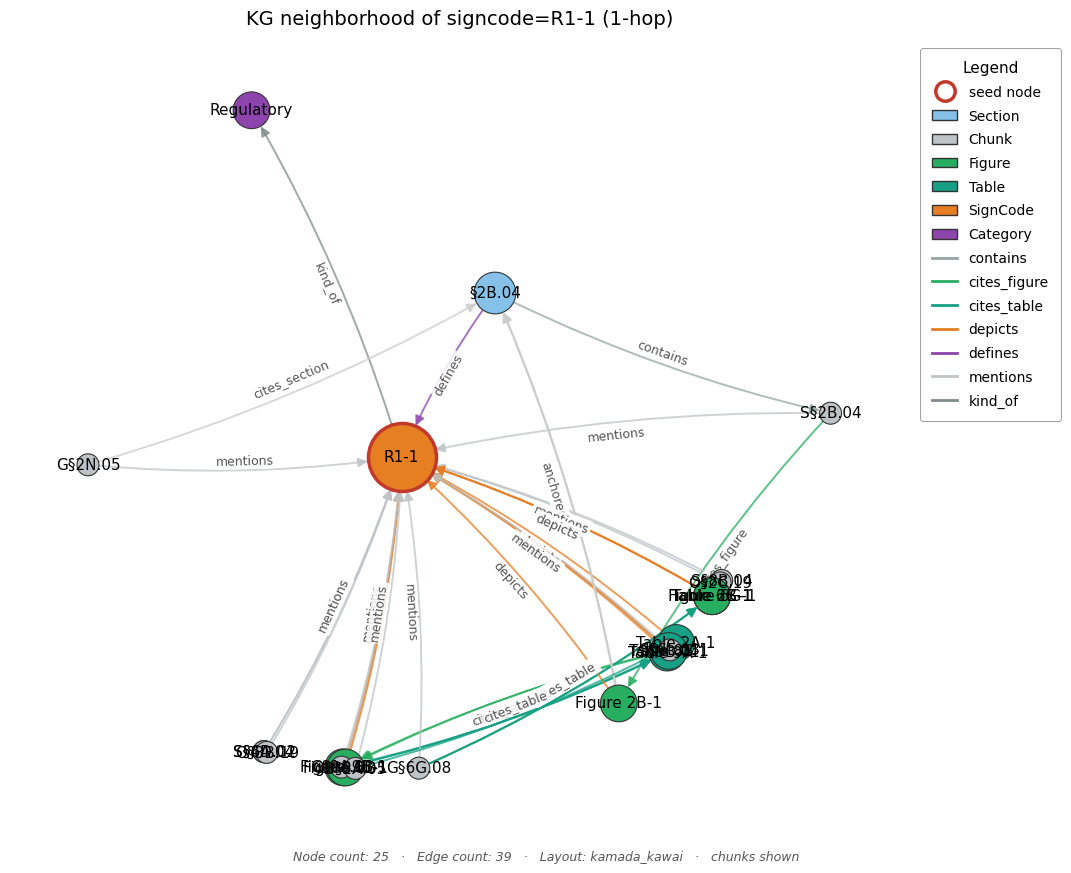

[visualize_kg] view='signcode' target='R1-1' n_hops=1 paper=True
  Paper subgraph: 12 nodes, 14 edges (chunks hidden)
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.pdf
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.png


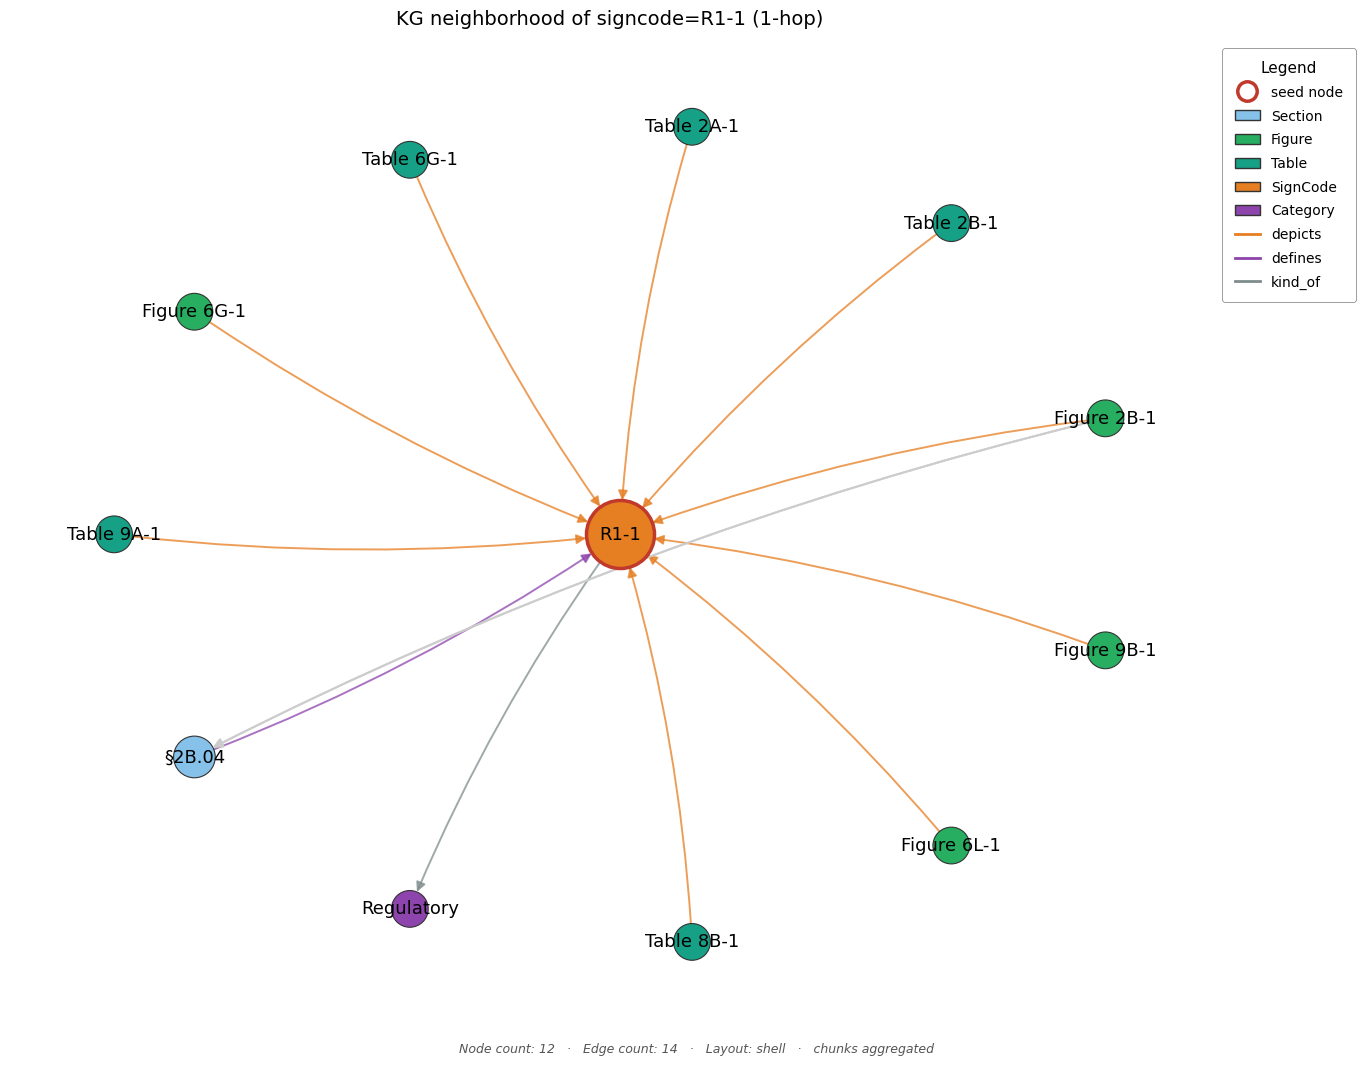

[visualize_kg] view='signcode' target='R1-1' n_hops=1 paper=True
  Paper subgraph: 12 nodes, 14 edges (chunks hidden)
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.pdf
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.png


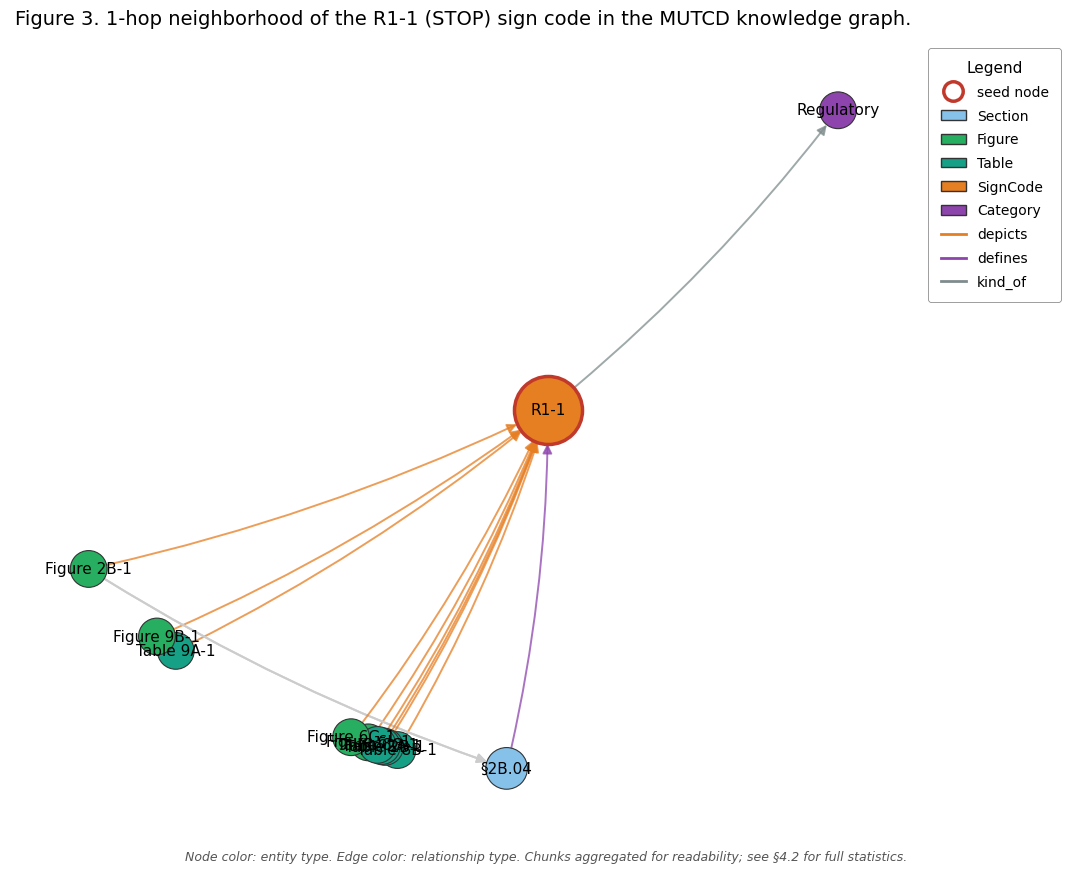

In [16]:
# Default paper mode — chunks hidden, deterministic layout, PDF + PNG
visualize_kg("signcode", "R1-1", n_hops=1, paper=True)

# Keep chunks, show edge type text labels
visualize_kg("signcode", "R1-1", n_hops=1, paper=True,
             include_chunks=True, show_edge_labels=True)

# Bigger figure, different layout
visualize_kg("signcode", "R1-1", n_hops=1, paper=True,
             figsize=(14, 11), layout="shell", label_fontsize=13)

# Custom title/caption for the paper
visualize_kg("signcode", "R1-1", n_hops=1, paper=True,
             title="Figure 3. 1-hop neighborhood of the R1-1 (STOP) sign code in the MUTCD knowledge graph.",
             caption="Node color: entity type. Edge color: relationship type. "
                     "Chunks aggregated for readability; see §4.2 for full statistics.")

[visualize_kg] view='signcode' target='R1-1' n_hops=1 paper=True
  Paper subgraph: 25 nodes, 39 edges (chunks kept)
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.pdf
  saved -> /content/drive/MyDrive/MRAG/kg_viz/kg_paper_signcode_R1-1_1h.png


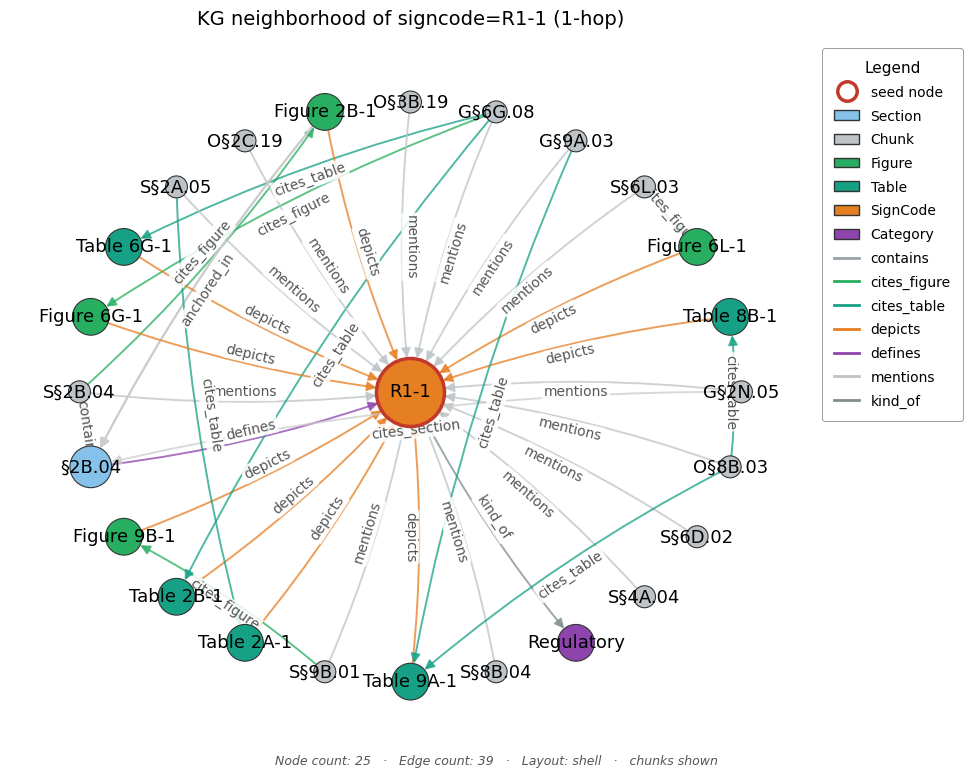

In [19]:
visualize_kg(view="signcode", target="R1-1", n_hops=1, paper=True,
             include_chunks=True, show_edge_labels=True,
             figsize=(10, 8), layout="shell",
             label_fontsize=13,          # node labels (Section, Figure, chunks)
             edge_label_fontsize=10,     # edge labels (mentions, depicts, ...)
             #title_fontsize=20,          # top title
             #caption_fontsize=12,        # bottom caption line
             #legend_fontsize=17,         # legend items
             #legend_title_fontsize=18,   # "Legend" text itself
)

In [ ]:
# Neighbourhood of a sign code
# (fill in a real sign code node id from your graph, e.g. "signcode:R1-1")


In [ ]:
# Which figures does Section 2B.04 directly link to via cross-references in its chunks?


## 5. Debug retrieval (no VLM call)

In [ ]:
from mrag.retrieval import Retriever


## 6. MUTCD-150 model-loop benchmark — GitHub assets, Drive outputs

This section runs the fixed, question-only **MUTCD-150-v1.0** benchmark over any enabled VLMs using runner **v1.1**.

- **Read from GitHub clone:** runner and immutable question-only JSONL.
- **Persist in Google Drive:** editable model-registry override and all run outputs.
- **Never present in this runtime:** gold answers, M-SDI annotations, and evaluator scoring metadata.
- **Runner v1.1:** detects wrapper strings beginning with `(VLM error:)`, retries them, and records unresolved failures in `errors_<run_id>.jsonl` instead of treating them as successful answers.

Run the earlier cells through pipeline initialization first. `CFG`, `pipeline`, and `ask` must exist.


In [ ]:
# Load benchmark runtime assets directly from the cloned GitHub repository.
# No manual Colab upload is required.
import hashlib
import json
import shutil
import sys
from pathlib import Path

REPO_ROOT = Path(globals().get("MRAG_REPO_DIR", "/content/MRAG"))
REPO_BENCH_DIR = REPO_ROOT / "benchmarks" / "mutcd150" / "v1"
DRIVE_BENCH_DIR = Path(CFG.base_dir) / "benchmarks" / "mutcd150" / "v1"
DRIVE_BENCH_DIR.mkdir(parents=True, exist_ok=True)

RUNNER_PATH = REPO_BENCH_DIR / "mutcd_benchmark_runner.py"
QUESTIONS_PATH = REPO_BENCH_DIR / "mutcd_benchmark_questions_v1.jsonl"
REPO_MODEL_REGISTRY_PATH = REPO_BENCH_DIR / "model_registry.json"
RUNTIME_MANIFEST_PATH = REPO_BENCH_DIR / "runtime_manifest.json"

EXPECTED_QUESTIONS_SHA256 = "3a04b1d620a80704eefac34c565449a0cb8814e781dd6d73b8afb77318b954b2"


def _sha256(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


required_assets = [
    RUNNER_PATH,
    QUESTIONS_PATH,
    REPO_MODEL_REGISTRY_PATH,
    RUNTIME_MANIFEST_PATH,
]
missing = [str(p) for p in required_assets if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Benchmark assets are missing from the cloned repository. "
        "Run the GitHub deployment script and restart/update the repo. Missing: "
        + ", ".join(missing)
    )

actual_hash = _sha256(QUESTIONS_PATH)
if actual_hash != EXPECTED_QUESTIONS_SHA256:
    raise ValueError(
        "Wrong or modified question file.\n"
        f"Expected: {EXPECTED_QUESTIONS_SHA256}\n"
        f"Received: {actual_hash}"
    )

# Persistent, editable model registry. The repository registry is copied only
# once; later changes made in Drive survive Colab restarts and git pulls.
DRIVE_MODEL_REGISTRY_PATH = DRIVE_BENCH_DIR / "model_registry.json"
if not DRIVE_MODEL_REGISTRY_PATH.exists():
    shutil.copy2(REPO_MODEL_REGISTRY_PATH, DRIVE_MODEL_REGISTRY_PATH)
    print("Created Drive model registry from repository default:", DRIVE_MODEL_REGISTRY_PATH)
else:
    print("Using existing Drive model registry:", DRIVE_MODEL_REGISTRY_PATH)
MODEL_REGISTRY_PATH = DRIVE_MODEL_REGISTRY_PATH

sys.path.insert(0, str(REPO_BENCH_DIR))
if "mutcd_benchmark_runner" in sys.modules:
    del sys.modules["mutcd_benchmark_runner"]
from mutcd_benchmark_runner import run_benchmark, validate_run_outputs

runtime_manifest = json.loads(RUNTIME_MANIFEST_PATH.read_text(encoding="utf-8"))
print("Repository assets:", REPO_BENCH_DIR)
print("Runner           :", RUNNER_PATH)
print("Questions        :", QUESTIONS_PATH)
print("Registry override:", MODEL_REGISTRY_PATH)
print("Question hash    :", actual_hash)
print("Benchmark ID     :", runtime_manifest["benchmark_id"])


### 6.1 Select models without changing the benchmark

Edit the persistent file shown as `Registry override` in the previous cell—normally:

`MyDrive/MRAG/benchmarks/mutcd150/v1/model_registry.json`

The default is copied from GitHub only when the Drive file does not yet exist. `selector` may be a `CFG` catalog alias or an exact provider model ID. Adding future VLMs does not change the benchmark.


In [ ]:
registry_document = json.loads(MODEL_REGISTRY_PATH.read_text(encoding="utf-8"))
MODEL_REGISTRY = [m for m in registry_document["models"] if m.get("enabled", True)]

print("Enabled models:")
for m in MODEL_REGISTRY:
    print(f"  alias={m['alias']!r}  selector={m['selector']!r}  provider={m.get('provider')!r}")

if not MODEL_REGISTRY:
    raise ValueError("No models are enabled in the persistent Drive model_registry.json")

print("\nModels currently known to CFG:")
CFG.list_vlm_models()

### 6.2 Three-question smoke test

This verifies model switching, answer extraction, durable JSONL writes, and retrieval/debug capture. It uses only the first enabled model.

In [ ]:
OUTPUT_ROOT = Path(CFG.base_dir) / "benchmark_runs" / "mutcd150_v1"
SMOKE_RUN_ID = "mutcd150_v1_smoke"

smoke_paths = run_benchmark(
    CFG=CFG,
    ask_fn=ask,
    questions_path=QUESTIONS_PATH,
    output_root=OUTPUT_ROOT,
    run_id=SMOKE_RUN_ID,
    models=[MODEL_REGISTRY[0]],
    prompt_style="fewshot",
    replicates=1,
    max_questions=3,
    show_scores=True,
    show_text=True,
    max_attempts=3,
    retry_base_seconds=4.0,
    inter_request_seconds=1.0,
    resume=True,
    rerun_errors=True,
    strict_benchmark_hash=True,
    strict_question_count=True,
    store_serialized_return=True,
    store_raw_debug=True,
    echo_answer_preview=True,
)

smoke_summary = validate_run_outputs(smoke_paths["run_dir"], SMOKE_RUN_ID)
print(json.dumps(smoke_summary, indent=2))
assert smoke_summary["answer_records"] == 3
assert smoke_summary["ok_records"] == 3, "Inspect answers/retrieval JSONL before proceeding."

### 6.3 Full 150-question primary run

Review the smoke-test files first. Then set `RUN_FULL_BENCHMARK = True`. Keep the same `run_id` to resume an interrupted run or append a newly enabled model. Start a new `run_id` whenever the RAG configuration, prompt, source PDF, or repository version changes.

In [ ]:
RUN_FULL_BENCHMARK = False  # change to True only after the smoke test passes
PRIMARY_RUN_ID = "mutcd150_v1_primary"

if RUN_FULL_BENCHMARK:
    primary_paths = run_benchmark(
        CFG=CFG,
        ask_fn=ask,
        questions_path=QUESTIONS_PATH,
        output_root=OUTPUT_ROOT,
        run_id=PRIMARY_RUN_ID,
        models=MODEL_REGISTRY,
        prompt_style="fewshot",
        replicates=1,
        max_questions=None,       # all 150
        question_ids=None,
        show_scores=True,
        show_text=True,
        max_attempts=3,
        retry_base_seconds=4.0,
        inter_request_seconds=1.0,
        seed=20260710,
        resume=True,
        rerun_errors=True,
        strict_benchmark_hash=True,
        strict_question_count=True,
        store_serialized_return=True,
        store_raw_debug=True,
        echo_answer_preview=False,
    )
    primary_summary = validate_run_outputs(primary_paths["run_dir"], PRIMARY_RUN_ID)
    print(json.dumps(primary_summary, indent=2))
else:
    print("Full run is disabled. Set RUN_FULL_BENCHMARK = True after checking the smoke test.")

### 6.4 Rerun the five provider-failed flagship items

The first flagship run returned provider quota errors for five questions. The original 145 valid answers do **not** need to be rerun. This cell creates a separate retry run containing only those five IDs. Set `RUN_FLAGSHIP_RETRY = True` after quota is available.


In [ ]:
FAILED_FLAGSHIP_QUESTION_IDS = ["TB016", "TB022", "F007", "M006", "M021"]
RUN_FLAGSHIP_RETRY = False
FLAGSHIP_RETRY_RUN_ID = "mutcd150_v1_flagship_retry_01"

flagship_specs = [m for m in MODEL_REGISTRY if m.get("alias") == "flagship"]
if not flagship_specs:
    raise ValueError("Enable or add the 'flagship' model in the Drive model registry before retrying.")

if RUN_FLAGSHIP_RETRY:
    retry_paths = run_benchmark(
        CFG=CFG,
        ask_fn=ask,
        questions_path=QUESTIONS_PATH,
        output_root=OUTPUT_ROOT,
        run_id=FLAGSHIP_RETRY_RUN_ID,
        models=[flagship_specs[0]],
        prompt_style="fewshot",
        replicates=1,
        question_ids=FAILED_FLAGSHIP_QUESTION_IDS,
        show_scores=True,
        show_text=True,
        max_attempts=5,
        retry_base_seconds=8.0,
        inter_request_seconds=2.0,
        seed=20260710,
        resume=True,
        rerun_errors=True,
        strict_benchmark_hash=True,
        strict_question_count=True,
        store_serialized_return=True,
        store_raw_debug=True,
        echo_answer_preview=True,
    )
    retry_summary = validate_run_outputs(retry_paths["run_dir"], FLAGSHIP_RETRY_RUN_ID)
    print(json.dumps(retry_summary, indent=2))
    assert retry_summary["ok_records"] == len(FAILED_FLAGSHIP_QUESTION_IDS), (
        "Some retry items still failed. Inspect errors JSONL and rerun with the same run_id."
    )
else:
    print("Retry run disabled. Set RUN_FLAGSHIP_RETRY = True when provider quota is available.")


### 6.5 Validate and package a completed run

The ZIP should contain the answers, retrieval/debug trace, manifest, and any error file. Return this ZIP for scoring against the locked gold benchmark.

In [ ]:
# Set this to SMOKE_RUN_ID, PRIMARY_RUN_ID, or FLAGSHIP_RETRY_RUN_ID.
RUN_ID_TO_PACKAGE = PRIMARY_RUN_ID
run_dir_to_package = OUTPUT_ROOT / RUN_ID_TO_PACKAGE

if run_dir_to_package.exists():
    validation_summary = validate_run_outputs(run_dir_to_package, RUN_ID_TO_PACKAGE)
    print(json.dumps(validation_summary, indent=2))

    archive_base = Path(CFG.base_dir) / f"{RUN_ID_TO_PACKAGE}_outputs"
    archive_path = shutil.make_archive(str(archive_base), "zip", root_dir=run_dir_to_package)
    print("Archive:", archive_path)

    if CFG.environment == "colab":
        from google.colab import files
        # Uncomment to download directly from Colab:
        # files.download(archive_path)
else:
    print("Run directory does not exist yet:", run_dir_to_package)